# Neovariants Master Table 

### Pending 
- Clean code
- UMI combination analysis

In [1]:
#Load packages
library(tidyverse)
library(scales)
suppressMessages(library(BSgenome))
library(ggplot2)
library(dplyr)
library(broom) 
library(RColorBrewer)
library(DT)
library("stringi")
library(data.table)
library(ggalluvial)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘data.table’


The following object is masked from ‘package:GenomicRanges’:

    shift


The following object is masked from ‘package:IRanges’:

    shift


The following objects are masked from ‘package:S4Vectors’:

    first, second


The following objects are masked from ‘package:lu

## 1. Tidy data

In [2]:
df_summary <- read.csv("output/df_summary_complete.csv")

In [3]:
#data conversion define hierarchy
df_summary_tidy <- df_summary %>% 
separate(variation, into = c("variant1", "variant2"), sep = "-",remove = FALSE) %>% 
separate(umis, into = c("umis1", "umis2"), sep = "-",remove = FALSE) %>%
  mutate(original = case_when(
    nucl_po == variant1 ~ variant1,
    nucl_po == variant2 ~ variant2,
    TRUE ~ "unknown"
  )) %>%
  mutate(neovariant = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ "unknown",
    TRUE ~ NA
  )) %>%
  mutate(neovariant = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ "unknown",
    TRUE ~ NA
  )) %>%


  mutate(original2 = case_when(
    nucl_po == variant1 ~ variant1,
    nucl_po == variant2 ~ variant2,
    TRUE ~ NA
  )) %>%
  mutate(neovariant1 = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ variant1,
    nucl_po != variant2 & nucl_po == variant1 ~ variant2,
    nucl_po != variant1 & nucl_po != variant2 ~ variant1,
    TRUE ~ NA
  )) %>%
  mutate(neovariant2 = case_when(
    original == "unknown" & neovariant == "unknown" ~ variant2,
  )) %>% 
  mutate(original_umis = case_when(
    nucl_po == variant1 ~ umis1,
    nucl_po == variant2 ~ umis2,
    TRUE ~ NA
  )) %>%
  mutate(neovariant1_umis = case_when(
    nucl_po != variant1 & nucl_po == variant2 ~ umis1,
    nucl_po != variant2 & nucl_po == variant1 ~ umis2,
    nucl_po != variant1 & nucl_po != variant2 ~ umis1,
    TRUE ~ NA
  )) %>%
  mutate(neovariant2_umis = case_when(
    original == "unknown" & neovariant == "unknown" ~ umis2,
    TRUE ~ NA
      )) %>% select(-aid_motif1,-aid_motif2,-X)

In [4]:
# read data from Kees and change vgene_position_aligned `9999´ to allow posterior left_join
#events_v2 <- readxl::read_xlsx("~/repositories/FL_10X_2/310_Caught_in_the_act_AID/outs/paperTables/events.V2.0.xlsx") %>% 
events_v2 <- readxl::read_xlsx("input/events.V2.0.xlsx") %>% 
          mutate(vgene_position_aligned = case_when(vgene_position_aligned == 9999 ~ NA,
                                                   TRUE ~ vgene_position_aligned))

In [5]:
#Join Kees data and my data
events_v3 <- events_v2 %>% select(-nucl_po,-`AID motif`,-productive) %>% left_join(df_summary_tidy, by=c("subject","cell","subregion","variation","context_po","umis","vgene_position_aligned")) 

In [6]:
#reorder according to Kees order
events_v3 <- events_v3 %>% select(
 order,
  Chip,
  Sample,
  `Ig Chain`,
  `V(D)Jmutations`,
  `VDJmutations`,
  `VJmutations`,
  inBoth,
  `Cell ident`,
  subject,
  cell,
  subregion,
  position,
  vgene_position_aligned,
  context_po,
#  aid_motif,
  original2,
  neovariant1,
  neovariant2,
  original_umis,
  neovariant1_umis,
  neovariant2_umis,
  productive
) %>% dplyr::rename("original"="original2") 

In [7]:
WriteXLS::WriteXLS(events_v3,
                    "output/events.v3.0.xlsx" )


## 2. Calculate proportion FW/CDR in events

In [8]:
subregion <- df_summary %>% group_by(subregion) %>% count() %>% mutate(type = ifelse(str_detect(subregion, "^CDR"), "CDR", "FR"))
subregion

subregion,n,type
<chr>,<int>,<chr>
CDR1,152,CDR
CDR2,45,CDR
CDR3,91,CDR
FR1,284,FR
FR2,324,FR
FR3,302,FR
FR4,41,FR


In [9]:
subregion %>% group_by(type) %>% summarize(n_event=sum(n)) %>% mutate(Percentage =n_event * 100 / sum(n_event))

type,n_event,Percentage
<chr>,<int>,<dbl>
CDR,288,23.24455
FR,951,76.75545


## 3. Calculate the timing of neovariant

In [10]:
events_v3 <- readxl::read_xlsx("output/events.v3.0.xlsx")

In [11]:
events_v31 <- events_v3 %>% 
             mutate(h_from_event = log(original_umis/(original_umis+neovariant1_umis))/-0.231049) 


#### Cell count with neovariants by case

In [12]:
shm_cell_patient <- events_v31 %>% 
   group_by(Sample) %>%
   summarise(neovariant_cells = n_distinct(cell))

shm_cell_patient

Sample,neovariant_cells
<chr>,<int>
S10000,128
S11770,1
S12500,1
S13530,87
S13553,103
S144,40
S8934,4


In [13]:
# Total number of cells

print("Number of TOTAL cells with neovariants")
shm_cell_patient %>% pull(neovariant_cells) %>% sum()

[1] "Number of TOTAL cells with neovariants"


[1] 364

#### Events number by case

In [15]:
c_pos <-events_v31 %>%
  group_by(Sample) %>%
  summarise(n_events = n())

c_pos

Sample,n_events
<chr>,<int>
S10000,394
S11770,1
S12500,2
S13530,400
S13553,322
S144,116
S8934,4


#### Include a numeric cell ID (n_cell_ID)

In [16]:
# Extracting the ID numbers after "S" and creating a consecutive number according to the cellbarcode
events_v31 <- events_v31 %>%
  mutate(sample_number = as.numeric(sub("S", "", Sample))) %>%
  group_by(sample_number) %>%
  mutate(n_cell_ID = paste(sample_number, dense_rank(cell), sep = ".")) %>%
  ungroup() %>%
  select(-sample_number)

In [17]:
WriteXLS::WriteXLS(events_v31,
                    "output/events.v3.1.xlsx" )

## 4. Calculate cell numbers 

In [18]:
df_seq <- read.csv("output/UMI_consensus_all.csv")
head(df_seq)

,cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
,<chr>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGTGTTTGC,AATTGACGCG,174,1,1,TTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTC,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNTTTCTTATATGGGGGCTCTGGGAGACGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATCACTGAATACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCCAGTGTCAGGTGCAACTGGTGGAGTCTGGGGGAGACGTGGTCCAGCCTGGGAGGTCCCTGCGACTCAGCTGTTCAGCCTCTACTTTCACCTTCAACTCTTATACTATGCACTGGGTCCGCCAGGCTCCAGGCAAGGGGCCGGAGTGGGTGGCACTTATATCAGATAATGGATACACTTTATACTACGCCGACTCCGTGAGGGGCCGATTCACCGTCTCCAGAGACAATTCCAAGAACACCCTATATCTTCAAATGAACAGCCTAAGAGCTGAGGACACGGCTGTCTATTACTGTGCGACCAACTCCTCATTAAGTCGATATTATTATTTGGACGTCTGGGGCAGAGGCACCACGGTCACCGTCTCCACAGGGAGTGCATCCGCCCCAACCCTTTTCNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;15;15;15;15;15;15;16;16;16;16;16;16;16;16;17;105;106;106;107;109;109;111;112;114;114;114;114;116;117;120;120;123;123;123;123;123;124;124;126;126;126;126;127;127;127;127;128;128;128;128;128;128;128;128;129;128;127;127;127;127;127;128;128;129;129;129;129;129;130;130;130;130;130;129;129;131;131;131;132;132;132;132;129;129;129;129;131;129;129;129;130;130;129;129;129;129;129;128;128;127;125;123;122;122;122;119;118;118;118;118;117;115;115;115;114;115;113;113;113;112;41;43;44;44;44;45;44;45;45;45;45;45;46;46;45;45;45;45;45;46;45;45;45;44;44;45;44;43;43;43;43;43;44;44;45;45;45;44;44;44;43;43;41;40;40;40;40;40;39;38;37;37;34;34;34;34;34;34;35;34;34;34;34;33;33;33;33;32;32;32;33;33;33;33;33;33;33;33;33;33;33;33;33;33;31;32;32;33;33;33;33;33;33;33;33;33;31;31;30;28;28;28;29;29;29;29;29;27;26;26;26;25;25;25;26;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;25;26;24;24;24;23;23;23;22;21;21;21;20;20;19;19;20;20;20;20;20;19;19;19;18;18;17;17;17;16;16;16;15;15;15;15;14;14;14;13;13;12;12;12;12;12;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;10;10;10;10;10;10;10;10;10;10;10;10;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;6;6;5;5;5;5;5;5;5;5;6;7;7;7;7;7;7;6;6;6;6;6;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;5;5;6;6;6;6;6;6;6;6;6;6;6;6;6;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K1B_S10000-HC
2,AAACCTGGTCCAGTAT,ACCTCGAATG,109,1,1,ATTCGGTGATCATCACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAACTGGGTTCTCCTCGTTGCTCTTTTAAGAGGTGTCC

In [19]:
case_cell <- df_seq %>% 
   mutate(Patient_id = str_extract(subject, "(?<=_)[^_]+(?=-)"),diagnosis = case_when(str_detect(subject, "^K") ~ "FL",
                         str_detect(subject, "^Q") ~ "CLL",
                          TRUE ~ NA)) %>%
  mutate(experiment =sub("_(.*)$", "", subject)) %>%
   group_by(diagnosis,Patient_id) %>% #experiment
    summarise(total_cell = n_distinct(cell)) %>%
    replace(is.na(.), 0) 
case_cell

`summarise()` has grouped output by 'diagnosis'. You can override using the
`.groups` argument.


diagnosis,Patient_id,total_cell
<chr>,<chr>,<int>
CLL,S356,1027
CLL,S4725,1112
CLL,S5714,1069
CLL,S7482,644
CLL,S9856,587
FL,S10000,8938
FL,S10971,1089
FL,S11770,215
FL,S12118,848


### D) Number of event (positions) by cell

In [20]:
#pos by cell
pbc <- df_summary %>% #filter(source == "K2B_S12500_L")
   group_by(subject, cell) %>%
   summarise(pos_by_cell = n_distinct(vgene_position_aligned)) %>%
   mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)"))
head(pbc)

`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


subject,cell,pos_by_cell,case
<chr>,<chr>,<int>,<chr>
K1B_S10000-LC,AGCTTGACAATGGACG,2,S10000
K1B_S10000-LC,CGAGCACAGGTTCCTA,1,S10000
K1B_S10000-LC,CTAGCCTCAATCACAC,1,S10000
K1B_S144-LC,AACCGCGAGGTGCTAG,1,S144
K1B_S144-LC,AACTCAGCATTCGACA,1,S144
K1B_S144-LC,AAGGTTCGTTGTACAC,3,S144


In [21]:
pbc %>% group_by(pos_by_cell) %>% summarize(n=n()) %>% mutate(percentage= n * 100 / sum(n))

pos_by_cell,n,percentage
<int>,<int>,<dbl>
1,109,26.2019231
2,106,25.4807692
3,61,14.6634615
4,56,13.4615385
5,35,8.4134615
6,27,6.4903846
7,12,2.8846154
8,6,1.4423077
9,3,0.7211538


## 5. Incorporate Syn/NonSyn data (Check problem of UMIS with NA)

In [22]:
events_v31 <- readxl::read_xlsx("output/events.v3.1.xlsx")

In [23]:
## Load all SHMss events detected (positive + false positive)
df <- Sys.glob("input/results_20231120/FL/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciicccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

In [24]:
head(df)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,context_cc,codon_cc,aa_ref_cc,aa_alt_cc,nucl_po,subregion,subject
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACGGGCATCACGTA,GCAGGCAGTG,290,G,T,NN.TT,9,TRUE,L,NA,NA,CA.CC,NA,NA,NA,-,-,K1B_S10000-HC
AAACGGGCATCACGTA,TAGCCGTATA,290,G,G,CA.CC,91,TRUE,L,NA,NA,CA.CC,NA,NA,NA,-,-,K1B_S10000-HC
AAACGGGCATCACGTA,TCACTTGGCC,290,G,G,CA.CC,98,TRUE,L,NA,NA,CA.CC,NA,NA,NA,-,-,K1B_S10000-HC
AACCGCGGTAAATGTG,CGAAGAGGGC,290,G,G,CA.CC,83,TRUE,L,NA,NA,CA.CC,NA,NA,NA,-,-,K1B_S10000-HC
AACCGCGGTAAATGTG,GTTGTAAGCC,290,G,T,NN.TT,9,TRUE,L,NA,NA,CA.CC,NA,NA,NA,-,-,K1B_S10000-HC
ACCAGTACATTTCAGG,GGTTACGCAT,290,G,G,CA.CC,76,TRUE,L,NA,NA,CA.CC,NA,NA,NA,-,-,K1B_S10000-HC


In [26]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v32 <- events_v31 %>% left_join(df %>% select(subject,cell,subregion,position,codon_cc,aa_ref_cc,aa_alt_cc,nucl,context_cc,nucl_po), by=c("subject","cell","subregion","position")) %>% unique() %>% 
mutate(aminoacid_original=if_else(nucl == original,aa_alt_cc,NA)) %>% 
mutate(aminoacid_n1=if_else(nucl == neovariant1,aa_alt_cc,NA)) %>%
mutate(aminoacid_n2=if_else(nucl == neovariant2,aa_alt_cc,NA)) %>%
 group_by(order,Chip,Sample,`Ig Chain`,	`V(D)Jmutations`,	`VDJmutations`,
          `VJmutations`,`inBoth`,`Cell ident`,subject,cell,subregion,position,vgene_position_aligned,
          context_po,context_cc,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc) %>%
  summarise(
    aminoacid_original = na.omit(aminoacid_original)[1],
    aminoacid_n1 = na.omit(aminoacid_n1)[1],
    aminoacid_n2 = na.omit(aminoacid_n2)[1],
    .groups = 'drop' # to drop the grouping after summarising
  ) %>% mutate(
    mutation_type = case_when(
      aminoacid_original == aminoacid_n1 ~ "silent",
      (!is.na(aminoacid_original)) & aminoacid_n1 == "*" ~ "nonsense",
      aminoacid_original == "*" ~ "stop-loss",
      aminoacid_original != aminoacid_n1 ~ "missense",
      TRUE ~ NA_character_
    )
  )

### 6. Include modifications to master table like:
 - Generate full context (5 nt) 
 - Generate a full context (5 nt) for every neovariant 1 and 2 when there is not original
 - Calculate again the AID motif now using the cell context
- Define in which strand it was found the motif
 - Identify if the motif are destroyed with the neovariant

In [27]:
#events_v33 <- readxl::read_xlsx("output/events.v3.1.xlsx")

In [28]:
# Generate full context (5 nt) and also with context_cc
events_v33 <- events_v32 %>%
              mutate(nucl_po = toupper(nucl_po)) %>% mutate(context_po_coding_strand = stri_replace_first_fixed(context_po, ".", nucl_po)) %>% 
              mutate(context_cc_po = stri_replace_first_fixed(context_cc, ".", original)) %>% 
              mutate(variation_delete = case_when(is.na(original) ~ NA, !is.na(original) ~ paste0(original,"-",neovariant1))) %>%
              mutate(variation_delete2 = case_when(is.na(original) ~ paste0(neovariant1,"-",neovariant2), !is.na(original) ~ NA))

In [30]:
head(events_v33)

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,context_cc,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type,context_po_coding_strand,context_cc_po,variation_delete,variation_delete2
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,CA.TG,G,G,C,NA,45,79,NA,TRUE,4.387031,10000.1,XTG,V,L,NA,missense,CAGTG,CAGTG,G-C,NA
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,GC.GA,GC.GA,A,A,C,NA,21,16,NA,TRUE,2.451408,10000.2,GCX,A,A,NA,silent,GCAGA,GCAGA,A-C,NA
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,CT.TA,CT.TA,G,G,C,NA,16,14,NA,TRUE,2.720672,10000.2,CTX,L,L,NA,silent,CTGTA,CTGTA,G-C,NA
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,CT.AG,CT.AG,G,NA,A,C,NA,12,13,TRUE,NA,10000.2,CTX,NA,L,L,NA,CTGAG,NA,NA,A-C
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,GA.GA,GA.GA,G,G,C,NA,12,14,NA,TRUE,3.346433,10000.2,GAX,E,D,NA,missense,GAGGA,GAGGA,G-C,NA
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,GG.CA,GG.CA,G,G,A,NA,16,39,NA,TRUE,5.344081,10000.3,GGX,G,G,NA,silent,GGGCA,GGGCA,G-A,NA


### Identify AID motifs

In [31]:
# Modification of AID motif to identify motif forward and reverse
aidp2 <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT].")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."))
)

In [32]:
# Function to get reverse complement, handles NA
get_rev_comp <- function(s) {
  if (is.na(s)) return(NA)
  dna_s <- DNAString(s)
  return(as.character(reverseComplement(dna_s)))
}

# Custom function to get complement without reversing
get_complement <- function(seq) {
  # Define the complement mapping
  complement_map <- c("A" = "T", "T" = "A", "G" = "C", "C" = "G", "-" = "-", "N" = "N")
  
  # Convert sequence string to character vector
  seq_vector <- strsplit(seq, '')[[1]]
  
  # Find the complement using the mapping
  complement_vector <- complement_map[seq_vector]
  
  # Convert back to a single string
  complement_seq <- paste0(complement_vector, collapse = "")
  
  return(complement_seq)
}

In [33]:
identify_aid_patterns_bystrand <- function(mutation, context, aid_patterns = aidp2) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [34]:
#Define AID motifs from consensus cell context (only for variation where is possible to define hierarchy)
events_v33$original_aid_motif1 <- mapply(identify_aid_patterns_bystrand, events_v33$variation_delete, events_v33$context_cc)
events_v33$original_aid_motif2 <- mapply(identify_aid_patterns_bystrand, sapply(events_v33$variation_delete, get_complement), sapply(events_v33$context_cc, get_rev_comp))

events_v33$neovariant_aid_motif1 <- mapply(identify_aid_patterns_bystrand, sapply(events_v33$variation_delete, reverse), events_v33$context_cc)
events_v33$neovariant_aid_motif2 <- mapply(identify_aid_patterns_bystrand, sapply(sapply(events_v33$variation_delete, reverse),get_complement), sapply(events_v33$context_cc, get_rev_comp))

In [35]:
#Define AID motifs from consensus cell context when there is not original nucleotide

# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

reverse_string <- function(x) {
  if (is.na(x)) {
    return(NA)
  }
  elements <- strsplit(x, "-")[[1]]
  reversed_elements <- rev(elements)
  return(paste(reversed_elements, collapse = "-"))
}

# Calculate AID motif for context cc with neovariant 1 or neovariant 2
events_v33$neovariant_1_aid_motif <- mapply(identify_aid_patterns, events_v33$variation_delete2, events_v33$context_cc)
events_v33$neovariant_2_aid_motif <- mapply(identify_aid_patterns, sapply(events_v33$variation_delete2, reverse_string), events_v33$context_cc)

In [36]:
# Rank motifs
events_v33 <- events_v33 %>% 
  mutate(original_aid_motif = case_when(is.na(original) ~ "Not_evaluated",
    original_aid_motif1 == "WRCY" | original_aid_motif2 == "WRCY" ~ "WRCY",
    original_aid_motif1 == "WA" | original_aid_motif2 == "WA" ~ "WA",
    original_aid_motif1 == "RCG" | original_aid_motif2 == "RCG" ~ "RCG",
    original_aid_motif1 == "None" | original_aid_motif2 == "None" ~ "None",
    TRUE ~ NA
  )) %>%  
    mutate(neovariant_aid_motif = case_when(
    is.na(original) ~ "Not_evaluated",
    neovariant_aid_motif1 == "WRCY" | neovariant_aid_motif2 == "WRCY" ~ "WRCY",
    neovariant_aid_motif1 == "WA" | neovariant_aid_motif2 == "WA" ~ "WA",
    neovariant_aid_motif1 == "RCG" | neovariant_aid_motif2 == "RCG" ~ "RCG",
    neovariant_aid_motif1 == "None" | neovariant_aid_motif2 == "None" ~ "None",
    TRUE ~ NA
  )) %>% 
  mutate(motif_destroyed = case_when(
    original_aid_motif == "None"  ~ "No_motif", #& neovariant_aid_motif == "None"
        is.na(variation_delete) ~ "No_evaluated",
    original_aid_motif == neovariant_aid_motif ~ "FALSE",
    !is.na(original_aid_motif) & is.na(neovariant_aid_motif) ~ "TRUE",
    original_aid_motif != neovariant_aid_motif ~ "TRUE",
    is.na(original_aid_motif) ~ "No_motif",
    TRUE ~ "Other" # catches all other cases, can be removed if not needed
  ))  %>%
  mutate(strand_of_motif = case_when(
    original_aid_motif1 != "None" ~ "coding",
    original_aid_motif2 != "None" ~ "non-coding",
    is.na(original) ~ "Not_evaluated",
    original_aid_motif1 == "None" & original_aid_motif2 == "None" ~ "No-motif",
    TRUE ~ "Other"  # For any other cases, can be removed if not needed
   )) %>%
  mutate(motif_destroyed_neovariant = case_when(
    neovariant_aid_motif == "None"  ~ "No_motif",
        is.na(original) ~ "No_evaluated",
    original_aid_motif == neovariant_aid_motif ~ "FALSE",
    !is.na(original_aid_motif) & is.na(neovariant_aid_motif) ~ "TRUE",
    original_aid_motif != neovariant_aid_motif ~ "TRUE",
    is.na(neovariant_aid_motif) ~ "No_motif",
    TRUE ~ "Other" # catches all other cases, can be removed if not needed
  ))  

In [37]:
#delete all the columns that I do not need more
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v34 <- events_v33 %>% select(-subject,-`Cell ident`,-context_po,-context_cc,-variation_delete,-variation_delete2,-original_aid_motif1,-original_aid_motif2,-neovariant_aid_motif1,-neovariant_aid_motif2,
                       -neovariant_1_aid_motif,-neovariant_2_aid_motif,
                      -context_po,-context_cc,-vgene_position_aligned)

In [38]:
events_v34 %>% filter(is.na(codon_cc))#filter(productive == "MIXED", mutation_type == "missense")

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,cell,subregion,position,nucl_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID,codon_cc,aminoacid_original,aminoacid_n1,aminoacid_n2,mutation_type,context_po_coding_strand,context_cc_po,original_aid_motif,neovariant_aid_motif,motif_destroyed,strand_of_motif,motif_destroyed_neovariant
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
21,K7B,S10000,H,3,3,0,FALSE,AAGGTTCCAGCTGCAC,FR4,483,C,C,G,NA,10,21,NA,TRUE,4.896806,10000.10,NA,NA,NA,NA,NA,CTCA,CTCCA,None,None,No_motif,No-motif,No_motif
102,K7B,S10000,H,1,1,0,FALSE,CCGTACTTCATAGCAC,FR2,224,NA,A,C,NA,18,15,NA,TRUE,2.623408,10000.42,NA,NA,NA,NA,NA,NA,NA,None,None,No_motif,No-motif,No_motif
193,K7B,S10000,L,2,0,2,FALSE,GCATGCGCACCAGGCT,FR2,211,NA,G,A,NA,65,53,NA,TRUE,2.580826,10000.74,NA,NA,NA,NA,NA,NA,NA,None,None,No_motif,No-motif,No_motif
419,K6B,S13530,L,10,0,6,TRUE,ACCAGTACAGGGATTG,FR4,404,A,A,G,NA,18,56,NA,TRUE,6.118587,13530.3,NA,NA,NA,NA,NA,CCAAG,CCAAG,None,None,No_motif,No-motif,No_motif
470,K6B,S13530,L,11,0,9,TRUE,AGTGTCAAGAGGTTAT,FR4,404,A,A,G,NA,33,36,NA,TRUE,3.192392,13530.11,NA,NA,NA,NA,NA,CCAAG,CCAAG,None,None,No_motif,No-motif,No_motif
588,K6B,S13530,H,6,2,0,TRUE,CTGAAGTAGTTTAGGA,FR1,139,G,G,A,NA,48,62,NA,TRUE,3.589193,13530.34,NA,NA,NA,NA,NA,GAGGT,AAGGT,None,WA,No_motif,No-motif,TRUE
684,K6B,S13530,L,3,0,3,FALSE,GTCACAATCTGATTCT,FR4,404,A,A,G,NA,14,20,NA,TRUE,3.840325,13530.59,NA,NA,NA,NA,NA,CCAAG,CCAAG,None,None,No_motif,No-motif,No_motif
1144,K1B,S144,L,5,0,5,FALSE,AGTGTCACAGCTGGCT,FR2,203,NA,T,C,NA,11,14,NA,TRUE,3.553275,144.9,NA,NA,NA,NA,NA,NA,NA,None,None,No_motif,No-motif,No_motif


In [39]:
#WriteXLS::WriteXLS(events_v34,
#                    "output/working_table.v3.4.xlsx")

In [40]:
data_alluvial_v2 <- events_v33 %>% filter(!original_aid_motif %in% c("Not_evaluated", "None")) %>% group_by(original_aid_motif,motif_destroyed) %>% count()
data_alluvial_v2

original_aid_motif,motif_destroyed,n
<chr>,<chr>,<int>
RCG,TRUE,20
WA,FALSE,21
WA,TRUE,160
WRCY,FALSE,67
WRCY,TRUE,280


In [42]:
AID_colors = c("None" = "#d3d3d3", "RCG" = "#3ac5a4", "WA" = "#3c90be", "WRCY" = "#394abe")

your_data <- data_alluvial_v2

# Define the order you want for original_aid_motif
desired_order <- c("WRCY", "WA", "RCG")

# Set the levels of original_aid_motif according to the desired order
your_data$original_aid_motif <- factor(your_data$original_aid_motif, levels = desired_order)

ao <- ggplot(your_data, 
       aes(axis1 = original_aid_motif, axis2 = motif_destroyed, y = n)) +
  geom_alluvium(aes(fill = color), width = 1/12) +
  geom_stratum(width = 1/12, size = 1, fill = NA,linewidth=0.5) +  # Keep the second stratum transparent
#  scale_fill_brewer(palette = "Set1") +
  theme_minimal() +
  theme(
    legend.position = "none",
    axis.text.y = element_blank(),
    axis.text.x = element_blank(),
    axis.title = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank()
  )  +
  geom_text(stat = "stratum", aes(label = after_stat(stratum)), size = 3)

# ggsave("figs_paper/alluvial_original_motif.png", plot = ao, width = 7, height = 7, units = "cm", dpi = 300)
# ggsave("figs_paper/alluvial_original_motif.pdf", plot = ao, width = 7, height = 7, units = "cm")

In [43]:
data_alluvial_v3 <- events_v33 %>% filter(!neovariant_aid_motif %in% c("Not_evaluated", "None")) %>% group_by(neovariant_aid_motif,motif_destroyed_neovariant) %>% count()
data_alluvial_v3

neovariant_aid_motif,motif_destroyed_neovariant,n
<chr>,<chr>,<int>
RCG,TRUE,41
WA,FALSE,21
WA,TRUE,445
WRCY,FALSE,67
WRCY,TRUE,84


In [44]:
# Assign colors directly in the dataframe
data_alluvial_v3$color <- case_when(
  data_alluvial_v3$neovariant_aid_motif == "RCG" ~ "#3ac5a4",
  data_alluvial_v3$neovariant_aid_motif == "WA" ~ "#3c90be",
  data_alluvial_v3$neovariant_aid_motif == "WRCY" ~ "#394abe",
  TRUE ~ NA_character_  # Default, can be transparent (NA) or any color
)

your_data <- data_alluvial_v3

# Define the order you want for original_aid_motif
desired_order <- c("WRCY", "WA", "RCG")

# Set the levels of original_aid_motif according to the desired order
your_data$neovariant_aid_motif <- factor(your_data$neovariant_aid_motif, levels = desired_order)

ao <- ggplot(your_data, 
       aes(axis1 = neovariant_aid_motif, axis2 = motif_destroyed_neovariant, y = n)) +
  geom_alluvium(aes(fill = color), width = 1/12) +
  geom_stratum(width = 1/12, size = 1, fill = NA,linewidth=0.5) +  # Keep the second stratum transparent
#  scale_fill_brewer(palette = "Set1") +
  theme_minimal() +
  theme(
    legend.position = "none",
    axis.text.y = element_blank(),
    axis.text.x = element_blank(),
    axis.title = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank()
  )  +
  geom_text(stat = "stratum", aes(label = after_stat(stratum)), size = 3)

# ggsave("figs_paper/alluvial_neovariant_motif.png", plot = ao, width = 7, height = 7, units = "cm", dpi = 300)
# ggsave("figs_paper/alluvial_neovariant_motif.pdf", plot = ao, width = 7, height = 7, units = "cm")


### Neovariants data (save some code)

In [45]:
AID_motif_summ <- events_v33 %>% filter(!is.na(original)) %>% group_by(original_aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
mutate(AID=case_when(original_aid_motif == "None" ~ "No",
                          TRUE ~ "Yes"))  %>%
                 dplyr::rename("Motifs"="original_aid_motif") %>% mutate(group = "original")
AID_motif_summ

Motifs,n,Percentage,AID,group
<chr>,<int>,<dbl>,<chr>,<chr>
None,617,52.961373,No,original
RCG,20,1.716738,Yes,original
WA,181,15.536481,Yes,original
WRCY,347,29.785408,Yes,original


In [46]:
print('% AID-related motifs in FL neovariants')
AID_motif_summ %>% 
  filter(Motifs != "None") %>%
  summarise(total_percentage = sum(Percentage)) %>% pull(total_percentage)

[1] "% AID-related motifs in FL neovariants"


[1] 47.03863

In [47]:
AID_motif_summ_n <- events_v33 %>% filter(!is.na(original)) %>% group_by(neovariant_aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
mutate(AID=case_when(neovariant_aid_motif == "None" ~ "No",
                          TRUE ~ "Yes"))  %>%
                 dplyr::rename("Motifs"="neovariant_aid_motif")  %>% mutate(group = "neovariant")
AID_motif_summ_n

Motifs,n,Percentage,AID,group
<chr>,<int>,<dbl>,<chr>,<chr>
None,507,43.519313,No,neovariant
RCG,41,3.519313,Yes,neovariant
WA,466,40.000000,Yes,neovariant
WRCY,151,12.961373,Yes,neovariant


In [48]:
print('% AID-related motifs in FL neovariants')
AID_motif_summ_n %>% 
  filter(Motifs != "None") %>%
  summarise(total_percentage = sum(Percentage)) %>% pull(total_percentage)

[1] "% AID-related motifs in FL neovariants"


[1] 56.48069

In [49]:
AID_motif_all <- AID_motif_summ %>% bind_rows(AID_motif_summ_n)

In [50]:
AID_motif_all

Motifs,n,Percentage,AID,group
<chr>,<int>,<dbl>,<chr>,<chr>
None,617,52.961373,No,original
RCG,20,1.716738,Yes,original
WA,181,15.536481,Yes,original
WRCY,347,29.785408,Yes,original
None,507,43.519313,No,neovariant
RCG,41,3.519313,Yes,neovariant
WA,466,40.000000,Yes,neovariant
WRCY,151,12.961373,Yes,neovariant


In [51]:
purpleish = c("#B4617A", "#7266ae","#a09ece","#d9dbd5")

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


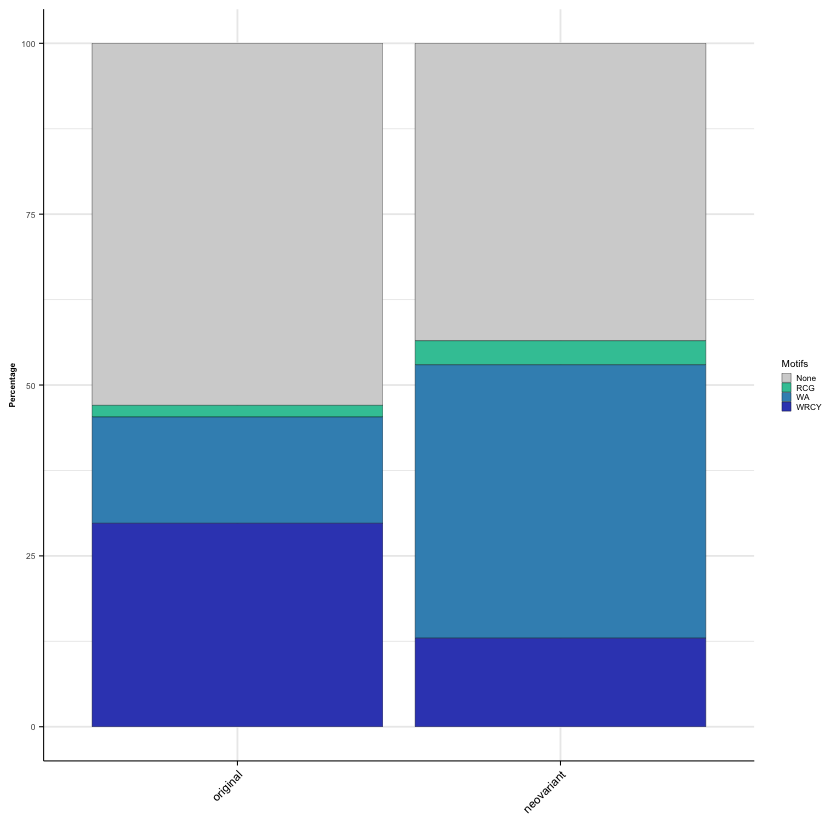

In [52]:

 df <- AID_motif_all
# Convert to factor to ensure the order of the bars
df$group <- factor(df$group, levels = c("original", "neovariant"))

# Create the stacked bar plot
p <- ggplot(df, aes(x = group, y = Percentage, fill = Motifs)) +
  geom_bar(stat = "identity",color="black",linewidth=0.1) +
  scale_fill_manual(values = c("None" = "#d3d3d3", "RCG" = "#3ac5a4", "WA" = "#3c90be", "WRCY" = "#394abe")) +
  theme_minimal() +
  theme(text = element_text(color = "black"),
    axis.title.x = element_text(size = 7, face = "bold",color = "black"),
    axis.title.y = element_text(size = 5, face = "bold",color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 7,color = "black"),
    axis.text.y = element_text(size = 5),
    legend.title = element_text(size = 6),
    legend.text = element_text(size = 5),
    legend.box.margin = margin(0, 0, 0, 0),  # Reduce margin around legend
    axis.line = element_line(linewidt = 0.3, colour = "black", linetype=1),
    axis.ticks = element_line(size = 0.3, color="black"),
  ) +
  labs(fill = "Motifs", x = "", y = "Percentage") +
  guides(fill = guide_legend(title.position = "top"))

# Remove the plot title
p <- p + theme(plot.title = element_blank())

# Increase the legend size (this is a bit tricky in ggplot2 but can be done through theme updates)
p <- p + theme(legend.key.size = unit(0.4, 'lines'))

# Adjust the size of the saved plot
ggsave("figs_paper/AID_bar_plot.png", plot = p, width = 7, height = 7, units = "cm", dpi = 300)
ggsave("figs_paper/AID_bar_plot.pdf", plot = p, width = 7, height = 7, units = "cm")

# Print the plot to the R console
print(p)


### IG from bulk data (mutational signature paper) 26 FL samples (-7 LUMC FL)

In [53]:
mutations_ig <- read.csv("../FL-CLL-MBL_filter/new_analysis_2020/ig_subset/data/df_ct_context.csv") %>% filter(lymph == "FL") %>% mutate(variation=paste0(ref,"-",alt))

In [54]:
head(mutations_ig)

,sample,lymph,chrom,pos,ref,alt,context2,context,substitution,variation
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,FL_01_1,FL,14,105863138,T,C,AA.GC,A.G,T>C,T-C
2,FL_01_1,FL,14,105863282,C,G,TC.TC,C.T,C>G,C-G
3,FL_01_1,FL,14,105863293,A,G,TT.TG,T.T,T>C,A-G
4,FL_01_1,FL,14,105863314,C,G,AC.TT,C.T,C>G,C-G
5,FL_01_1,FL,14,105863315,T,A,CC.TC,C.T,T>A,T-A
6,FL_01_1,FL,14,105863340,G,T,AG.TT,G.T,C>A,G-T


#### Include AID motifs (check from here, which code to identify motfs I should use?)

In [55]:
mutations_ig$aid_motif <- mapply(identify_aid_patterns, mutations_ig$variation, mutations_ig$context2)

#### Filter out 7 samples from FL (present in single cell data) and rank motifs

In [59]:
# filter out 7 samples from FL: 'FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'
mutations_ig <- mutations_ig %>% filter(!sample %in% c('FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'))

In [60]:
count_and_get_perc <- function(data, count_vars, group_vars) {
    counts <- data %>%
      dplyr::count(!!!count_vars) %>%
      dplyr::group_by(!!!group_vars) %>%
        dplyr::mutate(perc = n * 100 / sum(n)) %>%
      as.data.frame()
  
    return(counts)
}

count_aid_motifs <- function(data) {
  motif_counts <- count_and_get_perc(data,
                                     quos(subject, aid_motif1),
                                     quos(subject)) %>%
    dplyr::mutate(aid_motif = factor(aid_motif1,
                                     levels = c("WRCY", "WA", "RCG", "None")))

  return(motif_counts)
}

In [61]:
AID_motif_wes <-mutations_ig %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("aid_motif"="Motifs")
AID_motif_wes

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,389,46.642686,Yes
RCG,17,2.038369,Yes
WA,248,29.736211,Yes
WRCY,180,21.582734,Yes


In [62]:
print('% AID-related motifs in FL bulk')
(AID_motif_wes$Percentage[1] + AID_motif_wes$Percentage[2] + AID_motif_wes$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 78.41727

### IG from bulk data from Marcelo data

In [63]:
mutations_ig_m <- read.csv("input/igh_sanger_variant_analysis.csv")

In [64]:
mutations_ig_m <- mutations_ig_m %>% mutate(variation = paste0(ref,"-",alt)) 

In [65]:
head(mutations_ig_m)

,sample,V,D,J,pos,ref,alt,context,sig,variant,read_depth,ref_depth,alt_depth,allelic_depth,variation
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,10,C,T,AG.TG,WRCY,C/T,8,0,8,T:8,C-T
2,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,22,G,C,CC.GG,None,G/C,8,6,2,C:2,G-C
3,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,30,C,T,GG.TT,WRCY,C/T,8,6,2,T:2,C-T
4,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,89,G,C,CA.TA,WRCY,G/C,8,0,8,C:8,G-C
5,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,92,G,C,TA.CT,WRCY,G/C,8,0,8,C:8,G-C
6,A161KOB_GA,IGHV3-74*01,IGHD2-OF15*2,IGHJ4*02,93,C,T,AG.TA,WRCY,C/T,8,0,8,T:8,C-T


In [66]:
mutations_ig_m$aid_motif1 <- mapply(identify_aid_patterns, mutations_ig_m$variation, mutations_ig_m$context)
mutations_ig_m$aid_motif2 <- mapply(identify_aid_patterns, reverse(mutations_ig_m$variation), mutations_ig_m$context)

#### Rank motifs

In [67]:
# filter out 7 samples from FL: 'FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL'
mutations_ig_m <- mutations_ig_m %>% mutate(AIDmotif = paste0(aid_motif1,",",aid_motif2)) %>%
  mutate(aid_motif = case_when(
    aid_motif1 == "WRCY" | aid_motif2 == "WRCY" ~ "WRCY",
    aid_motif1 == "WA" | aid_motif2 == "WA" ~ "WA",
    aid_motif1 == "RCG" | aid_motif2 == "RCG" ~ "RCG",
    TRUE ~ NA
  )) 

In [68]:
AID_motif_m <-mutations_ig_m %>%  group_by(aid_motif) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(is.na(aid_motif) ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("aid_motif"="Motifs")
AID_motif_m

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
RCG,208,8.602151,Yes
WA,915,37.841191,Yes
WRCY,693,28.660050,Yes
NA,602,24.896609,No


In [69]:
AID_motif_m <-mutations_ig_m %>%  group_by(sig) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% 
                mutate(AID=case_when(sig == "None" ~ "No",
                          TRUE ~ "Yes"))  %>%
                 rename("sig"="Motifs")
AID_motif_m

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,1010,41.770058,No
RCG,110,4.549214,Yes
WA,444,18.362283,Yes
WRCY,854,35.318445,Yes


In [70]:
print('% AID-related motifs in FL bulk')
(AID_motif_m$Percentage[1] + AID_motif_m$Percentage[2] + AID_motif_m$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 64.68156

In [71]:
print('% AID-related motifs in FL bulk')
(AID_motif_m$Percentage[1] + AID_motif_m$Percentage[2] + AID_motif_m$Percentage[3])

[1] "% AID-related motifs in FL bulk"


[1] 64.68156

#### AID mutations between FL neovariant and FL (bulk)

#### Calculate p-value by motif

In [73]:
# Calculate total counts of 'n' for each source
total_counts <- AID_motifs %>% 
  group_by(Source) %>% 
  summarise(total_n = sum(n), .groups = "keep")

# Join total counts with the original data
AID_motifs <- AID_motifs %>%
  left_join(total_counts, by = "Source")

# Calculate counts for 'other' motifs
AID_motifs$other_n <- AID_motifs$total_n - AID_motifs$n

# Perform chi-squared test for each motif separately
results <- AID_motifs %>% 
  split(.$Motifs) %>% 
  map_df(~{
    test_result <- chisq.test(matrix(c(.$n, .$other_n), nrow = 2))
    tibble(Motifs = unique(.$Motifs), p_value = test_result$p.value)
  })

# Join p-values with the original data
AID_motifs <- AID_motifs %>%
  left_join(results, by = "Motifs")


In [74]:
AID_motifs

Motifs,n,Percentage,AID,group,Source,total_n,other_n,p_value
<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
None,617,52.961373,No,original,neovariants,1165,548,6.129022e-03
RCG,20,1.716738,Yes,original,neovariants,1165,1145,7.204740e-01
WA,181,15.536481,Yes,original,neovariants,1165,984,3.732034e-14
WRCY,347,29.785408,Yes,original,neovariants,1165,818,5.058307e-05
None,389,46.642686,Yes,NA,bulk,834,445,6.129022e-03
RCG,17,2.038369,Yes,NA,bulk,834,817,7.204740e-01
WA,248,29.736211,Yes,NA,bulk,834,586,3.732034e-14
WRCY,180,21.582734,Yes,NA,bulk,834,654,5.058307e-05


## 7. Substitution type (spectrum)

### Six Substituion pattern of all variant in 10x data

In [75]:
#clonotype information for K45678B
clonotype <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clones_2022_01_18.csv") %>% mutate(cell = gsub(".{2}$", "", barcode)) %>% 
 #            select(source, cell,chain,is_cell,productive,high_confidence,umis,reads,seqConcClone, ,cluster,seqConcCount)  %>% 
             mutate(gene=case_when(chain == "IGH" ~ "HC",
                                     chain == "IGK" | chain == "IGL" ~ "LC",
                                    TRUE ~ "NA"))

In [76]:
#clonotype information for K123B
clonotype_K13B <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clonesMulti_2022_06_09.csv") %>% mutate(source=paste0(source,"_",subject))

In [77]:
# default pairwise alignment
# to use for variable tasks
pairwiseAlignmentPreset <- function( pattern, subject, score ) {
  alignment <- pairwiseAlignment( pattern = pattern,
                                  subject = subject,
                                  type = "local",
                                  substitutionMatrix = nucleotideSubstitutionMatrix( match = 1,
                                                                                     mismatch = 0,
                                                                                     baseOnly = FALSE ),
                                  gapOpening = 5,
                                  gapExtension = 2,
                                  scoreOnly = score )
  return( alignment ) }


# # for K45678B 

# d<- read_csv( "~/repositories/FL_10X_2/250_Clonotypes/outs/clones_2022_01_18.csv" ) %>%
#      filter( source == "K4B" )

# po <- d %>% filter( contigId %like% "PO",chain == "IGH") %>% pull( seq )


# test <- d %>%
#     filter( seqClone == 1,
#     chain == "IGH" ) %>%
#     pull( seq ) %>%
#     unique()

# al<- pairwiseAlignmentPreset( toupper( po ),
#     toupper( test ),
#     score = FALSE )

# mm <- al@pattern@mismatch@unlistData

# subst <- sapply( 1: length( mm ),
#         function( i ){
#         list( substr( po, mm[ i ], mm[ i ]),
#         substr( test, mm[ i ], mm[ i ]) )
#         }) #%>% as.data.frame()

# colnames( subst ) <- mm

# subst <- subst %>% t() %>%
#          as.data.frame() %>%
#         rownames_to_column( var = "pos" ) %>%
#         mutate( subst = paste0( V1,"-", V2 ) )

In [78]:
perform_alignment_analysis <- function(input_df, output_file = "final_output_distinct.csv",
                                       source_col = 'source', chain_col = 'chain', seqClone_col = 'seqClone',
                                       contigId_col = 'contigId', seq_col = 'seq', score = FALSE) {
  # Initialize an empty data frame to store results
  final_output <- data.frame()
  
  # Fetch unique sources and chains
  unique_sources <- unique(input_df[[source_col]])
  unique_chains <- unique(input_df[[chain_col]])
  
  # Iterate over each unique source, chain, and seqClone
  for (src in unique_sources) {
    for (chn in unique_chains) {
      
      # Fetch the reference sequence (seqClone == 0 and contigId == "PO")
      ref_seq <- subset(input_df, input_df[[source_col]] == src & 
                                  input_df[[chain_col]] == chn & 
                                  input_df[[seqClone_col]] == 0 & 
                                  input_df[[contigId_col]] %like% "PO")[[seq_col]]
      
      if (length(ref_seq) == 0) next # Skip if no reference sequence
      
      # Fetch unique seqClone values, ignoring NA
      seqClones <- na.omit(unique(subset(input_df, input_df[[source_col]] == src & 
                                                  input_df[[chain_col]] == chn)[[seqClone_col]]))
      
      for (scl in seqClones) {
        if (scl == 0) next # Skip reference seqClone
        
        # Fetch the test sequence (ignoring NA and taking only the first sequence for each seqClone)
        test_seq <- na.omit(subset(input_df, input_df[[source_col]] == src & 
                                             input_df[[chain_col]] == chn & 
                                             input_df[[seqClone_col]] == scl)[[seq_col]])[1]
        
        # Perform the alignment
        alignment <- pairwiseAlignmentPreset(toupper(ref_seq), toupper(test_seq), score = score)
        
        # Extract the mismatch positions and bases
        mm <- alignment@pattern@mismatch@unlistData
        subst <- sapply(1:length(mm), function(i) {
          list(substr(ref_seq, mm[i], mm[i]), substr(test_seq, mm[i], mm[i]))
        })
        
        # Format and store the results
        if (length(mm) == 0) next # Skip if no mismatches
        colnames(subst) <- mm
        subst <- as.data.frame(t(subst))
        rownames(subst) <- mm
        subst$pos <- rownames(subst)
        subst$subst <- paste0(subst$V1, "-", subst$V2)
        subst[[source_col]] <- src
        subst[[seqClone_col]] <- scl
        
        # Append to final output
        final_output <- rbind(final_output, subst)
      }
    }
  }
  
  final_output_distinct <- final_output %>%
    distinct(pos, source, subst, .keep_all = TRUE)
  
  # Export the final output
  if (nrow(final_output_distinct) > 0) {
    write.csv(final_output_distinct[, c("pos", "subst", source_col, seqClone_col)], output_file, row.names=FALSE)
  } else {
    print("Final output is empty.")
  }
}


In [79]:
# Example usage
perform_alignment_analysis(clonotype, output_file = "output/final_output_distinct_K45678B.csv", source_col = "source")

In [80]:
# Example usage
perform_alignment_analysis(clonotype_K13B, output_file = "output/final_output_distinct_K123B.csv", source_col = "source")

In [81]:
K123B_subs <- read_csv("output/final_output_distinct_K123B.csv") %>% mutate(subst = toupper(subst))

Rows: 4515 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): subst, source
dbl (2): pos, seqClone

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [82]:
K45678B_subs <- read_csv("output/final_output_distinct_K45678B.csv") %>% mutate(subst = toupper(subst))

Rows: 2953 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): subst, source
dbl (2): pos, seqClone

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [83]:
six_pattern <- function(df, case_col, output_df_name) {
  case_col_sym <- sym(case_col)

  
  df_transformed <- df %>%
    mutate(
      substitution = case_when(
        !!case_col_sym == "G-T" ~ "C-A",
        !!case_col_sym == "G-C" ~ "C-G",
        !!case_col_sym == "G-A" ~ "C-T",
        !!case_col_sym == "A-T" ~ "T-A",
        !!case_col_sym == "A-G" ~ "T-C",
        !!case_col_sym == "A-C" ~ "T-G",
        TRUE ~ as.character(!!case_col_sym)
      )
    ) %>% filter(!substitution %in% c("A-A","C-C","G-G","T-T"))
  
  assign(output_df_name, df_transformed, envir = .GlobalEnv)
}

In [84]:
KBall_subs <- K123B_subs %>% bind_rows(K45678B_subs) %>% mutate(
    source = case_when(
      source == "K4B" ~ "K4B_S8934",
      source == "K5B" ~ "K5B_S8934",
      source == "K6B" ~ "K6B_S13530",
      source == "K7B" ~ "K7B_S10000",
      source == "K8B" ~ "K8B_S13553",
      TRUE ~ source
    )) 

six_pattern(
  KBall_subs, 
  case_col = "subst", 
  output_df_name = "KBall_subs_six_pattens"
)

### Group substitution by subject

In [85]:
KBall_subs_subject <- KBall_subs_six_pattens %>% group_by(source,substitution) %>% count() %>% group_by(source) %>% mutate(Percentage =n * 100 / sum(n)) %>%
                      dplyr::rename(subject=source) %>% mutate(source = "10x_bulk") 
head(KBall_subs_subject,12)

subject,substitution,n,Percentage,source
<chr>,<chr>,<int>,<dbl>,<chr>
K1B_S10000,C-A,45,10.613208,10x_bulk
K1B_S10000,C-G,83,19.575472,10x_bulk
K1B_S10000,C-T,132,31.132075,10x_bulk
K1B_S10000,T-A,48,11.320755,10x_bulk
K1B_S10000,T-C,67,15.801887,10x_bulk
K1B_S10000,T-G,49,11.556604,10x_bulk
K1B_S10971,C-A,12,8.571429,10x_bulk
K1B_S10971,C-G,25,17.857143,10x_bulk
K1B_S10971,C-T,41,29.285714,10x_bulk


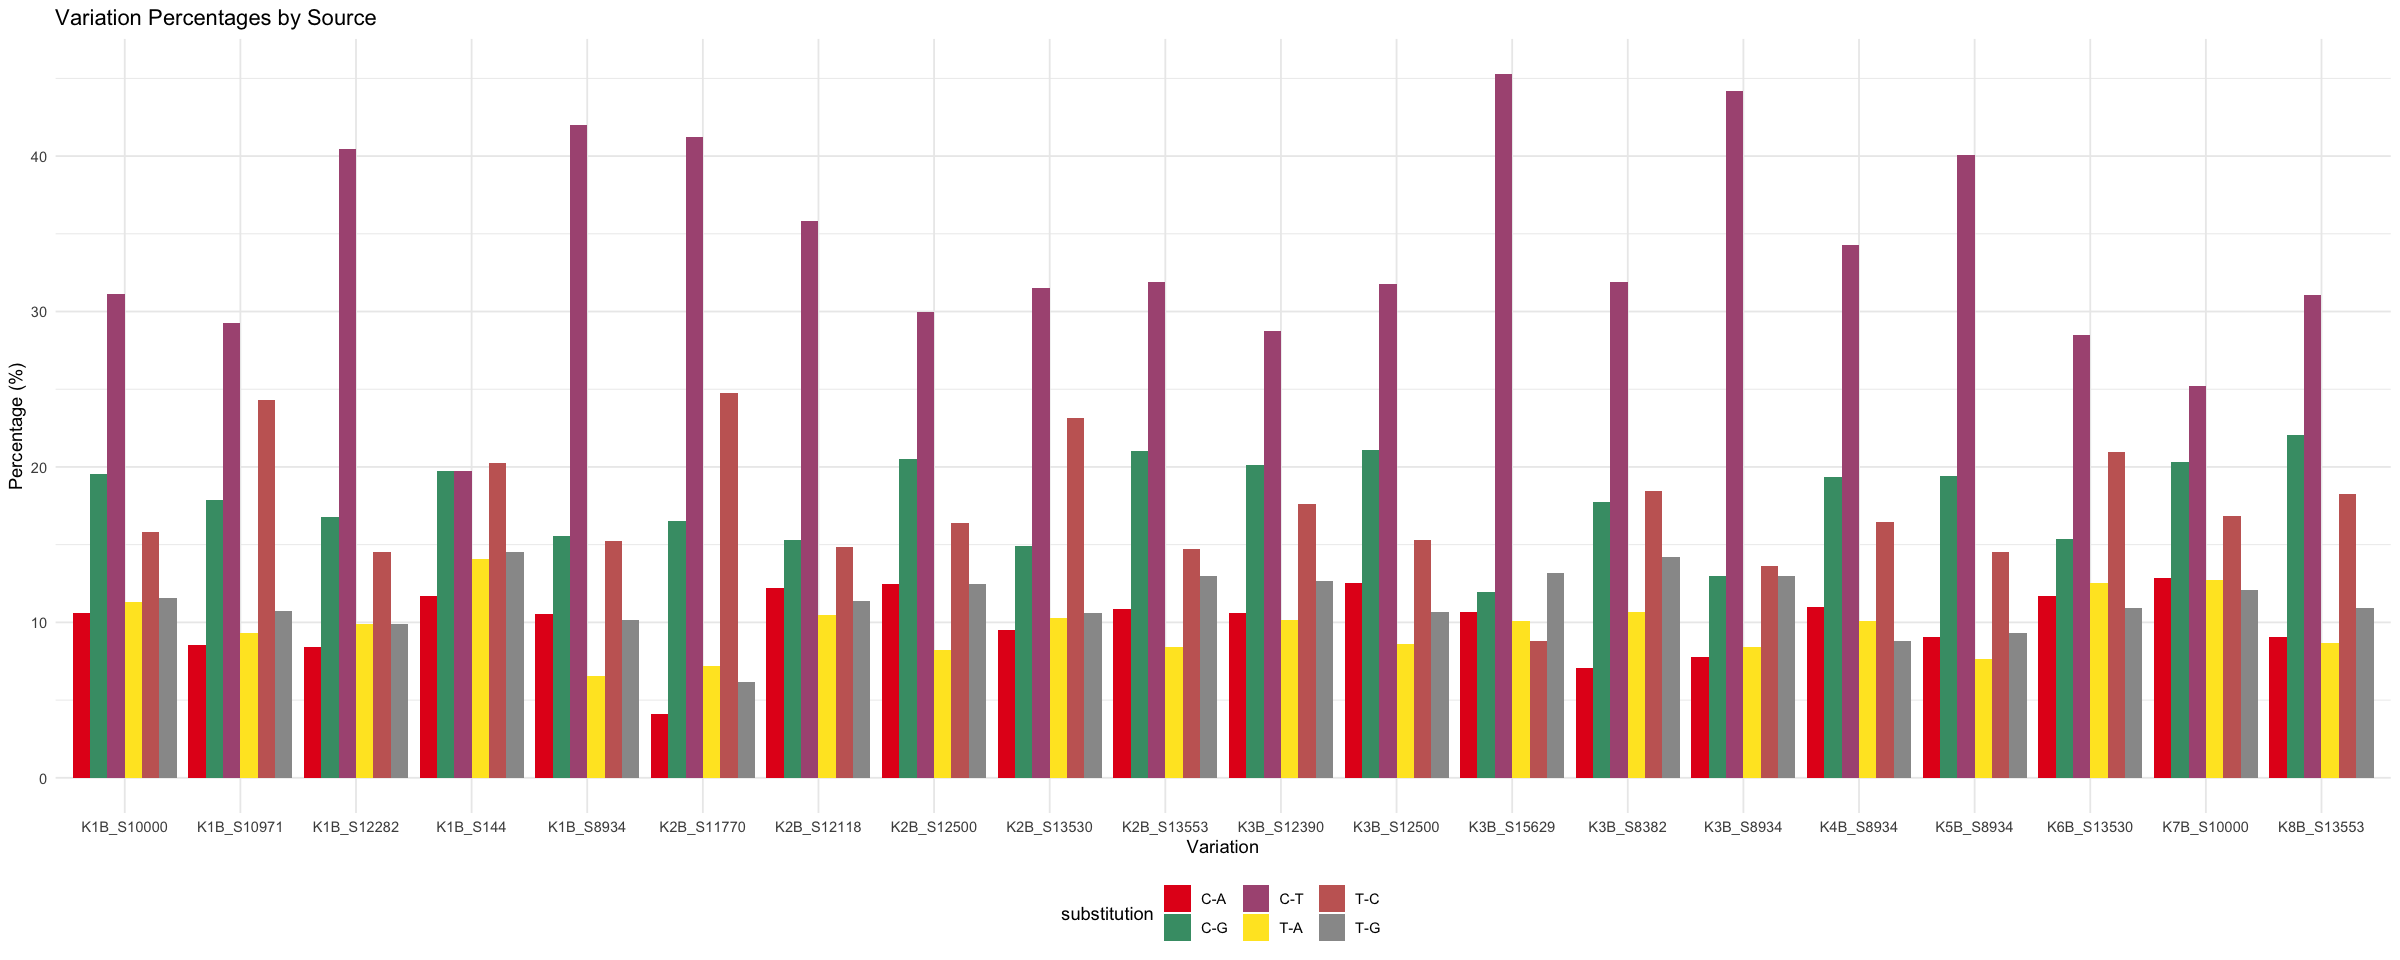

In [86]:
# Set plot dimensions
options(repr.plot.width=20, repr.plot.height=8)

# Generate a color palette with as many colors as there are variation types
my_palette <- colorRampPalette(brewer.pal(9, "Set1"))(length(unique(KBall_subs_subject$substitution)))

# Create bar plot
ggplot(KBall_subs_subject, aes(x = subject, y = Percentage, fill = substitution)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  theme_minimal() +
  labs(title = "Variation Percentages by Source", x = "Variation", y = "Percentage (%)") +
  scale_fill_manual(values = my_palette) +
  theme(legend.position = "bottom")


### Overall substituion

In [160]:
#data neovariant
# remove variation where we can not define hierarchy
spectro <- events_v33 %>% filter(!is.na(variation_delete)) %>% mutate(subject=str_replace(subject, "-[^-]+$", "")) 
                    
# transform substituion to six pattern
six_pattern(
  spectro, 
  case_col = "variation_delete", 
  output_df_name = "spectro"
)

spectro_subject <- spectro %>% group_by(subject,substitution) %>% count() %>% group_by(subject) %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "neoavariants")
spectro_summary <- spectro %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% mutate(source = "neoavariants") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 


ERROR: Error in filter(., !is.na(variation_delete)): object 'events_v33' not found


In [88]:
# data from muational signature filter by the subject used in 10x
mutations_ig <- mutations_ig %>%filter(!sample %in% c('FL_10000_LN','FL_10971_LN','FL_11770_LN','FL_12118_LN','FL_12282_LN','FL_8934_LN','FL_8934_PBL')) 

# transform substituion to six pattern
six_pattern(
  mutations_ig, 
  case_col = "variation", 
  output_df_name = "mutations_ig_spectro"
)

#Summary data by substitution
mutations_ig_spectro <- mutations_ig_spectro %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
mutate(source = "Ig_WES") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 

In [89]:
# data sanger Marcelo
# transform substituion to six pattern
six_pattern(
  mutations_ig_m, 
  case_col = "variation", 
  output_df_name = "mutations_ig_m_spectro"
)

# #Summary data by substitution
mutations_ig_m_spectro <- mutations_ig_m_spectro %>% group_by(substitution) %>% filter(substitution %in% mutations_ig_spectro$substitution) %>% 
                          count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
                        mutate(source = "Ig_sanger") %>% dplyr::rename(total_n=n) %>% select(source,everything()) 

In [90]:
#combine 4 data source 10x_bulk,spectro_summary,mutations_ig_spectro,mutations_ig_m_spectro

spectro_combine <- KBall_subs_six_pattens %>% group_by(substitution) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n)) %>% 
               mutate(source="10x_bulk") %>% dplyr::rename(total_n=n) %>% select(source,everything()) %>%
               bind_rows(spectro_summary,mutations_ig_spectro,mutations_ig_m_spectro )

In [91]:
head(spectro_combine)

source,substitution,total_n,Percentage
<chr>,<chr>,<int>,<dbl>
10x_bulk,C-A,807,10.81914
10x_bulk,C-G,1388,18.60839
10x_bulk,C-T,2351,31.51897
10x_bulk,T-A,760,10.18903
10x_bulk,T-C,1304,17.48224
10x_bulk,T-G,849,11.38222


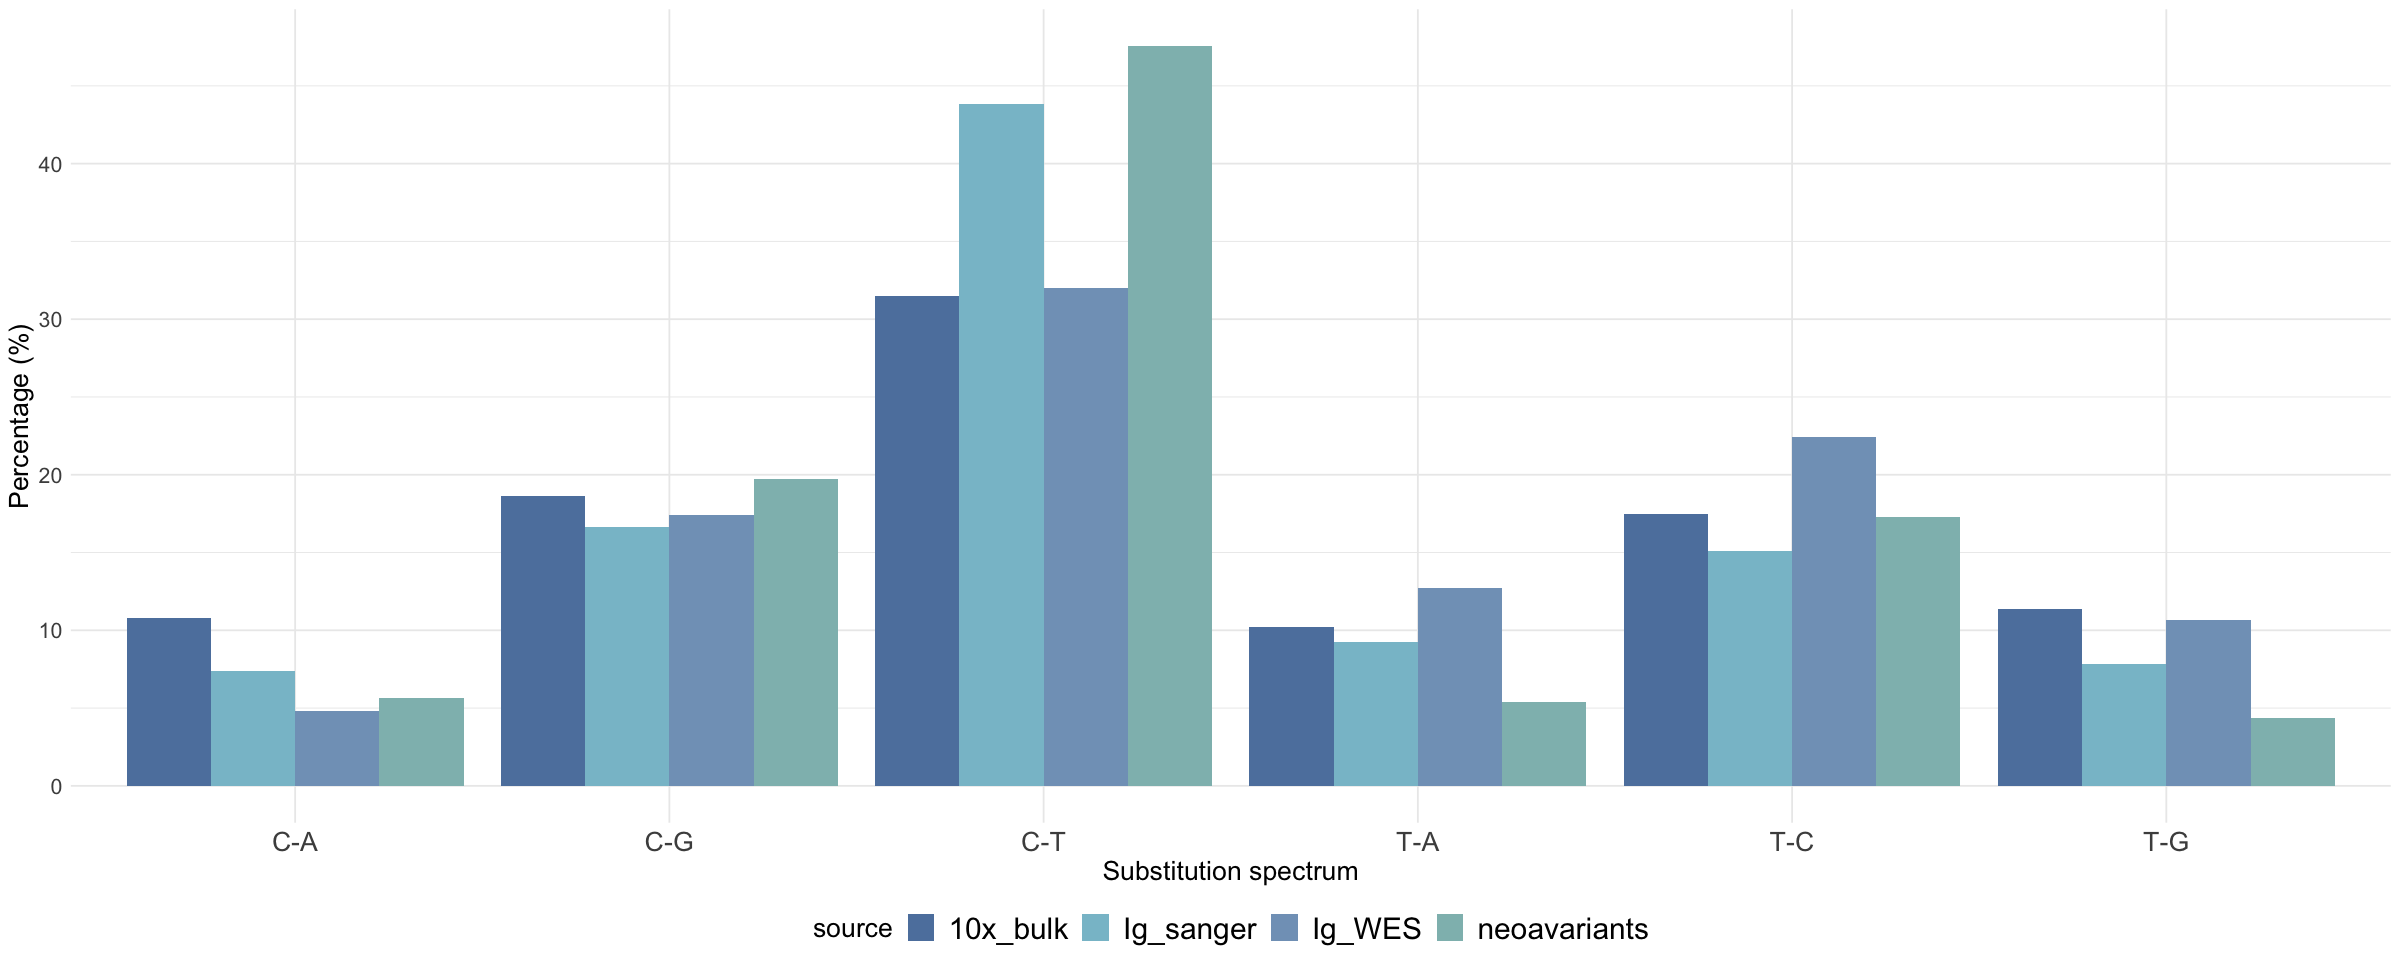

In [92]:
# Using a cool color palette
my_custom_palette <- c("#5E81AC", "#88C0D0", "#81A1C1", "#8FBCBB", "#B48EAD")

# Create bar plot
ggplot(spectro_combine, aes(x = substitution, y = Percentage, fill = source)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  theme_minimal() +
  labs( x = "Substitution spectrum", y = "Percentage (%)") +
  scale_fill_manual(values = my_custom_palette) +  # Use custom color palette
  theme(legend.position = "bottom",
        text = element_text(size = 16),  # Increase general text size
        axis.text.x = element_text(size = 16),  # Increase x-axis label size
        legend.text = element_text(size = 18),  # Increase legend text size
        plot.title = element_text(size = 16, hjust = 0.5))  # Increase title size and center it



In [93]:
# WriteXLS::WriteXLS(spectro_combine,
#                     "output/substitution_spectrum_aggregated.xlsx" )

In [94]:
spectro_combine

source,substitution,total_n,Percentage
<chr>,<chr>,<int>,<dbl>
10x_bulk,C-A,807,10.819145
10x_bulk,C-G,1388,18.608393
10x_bulk,C-T,2351,31.518970
10x_bulk,T-A,760,10.189033
10x_bulk,T-C,1304,17.482236
10x_bulk,T-G,849,11.382223
neoavariants,C-A,66,5.665236
neoavariants,C-G,230,19.742489
neoavariants,C-T,554,47.553648


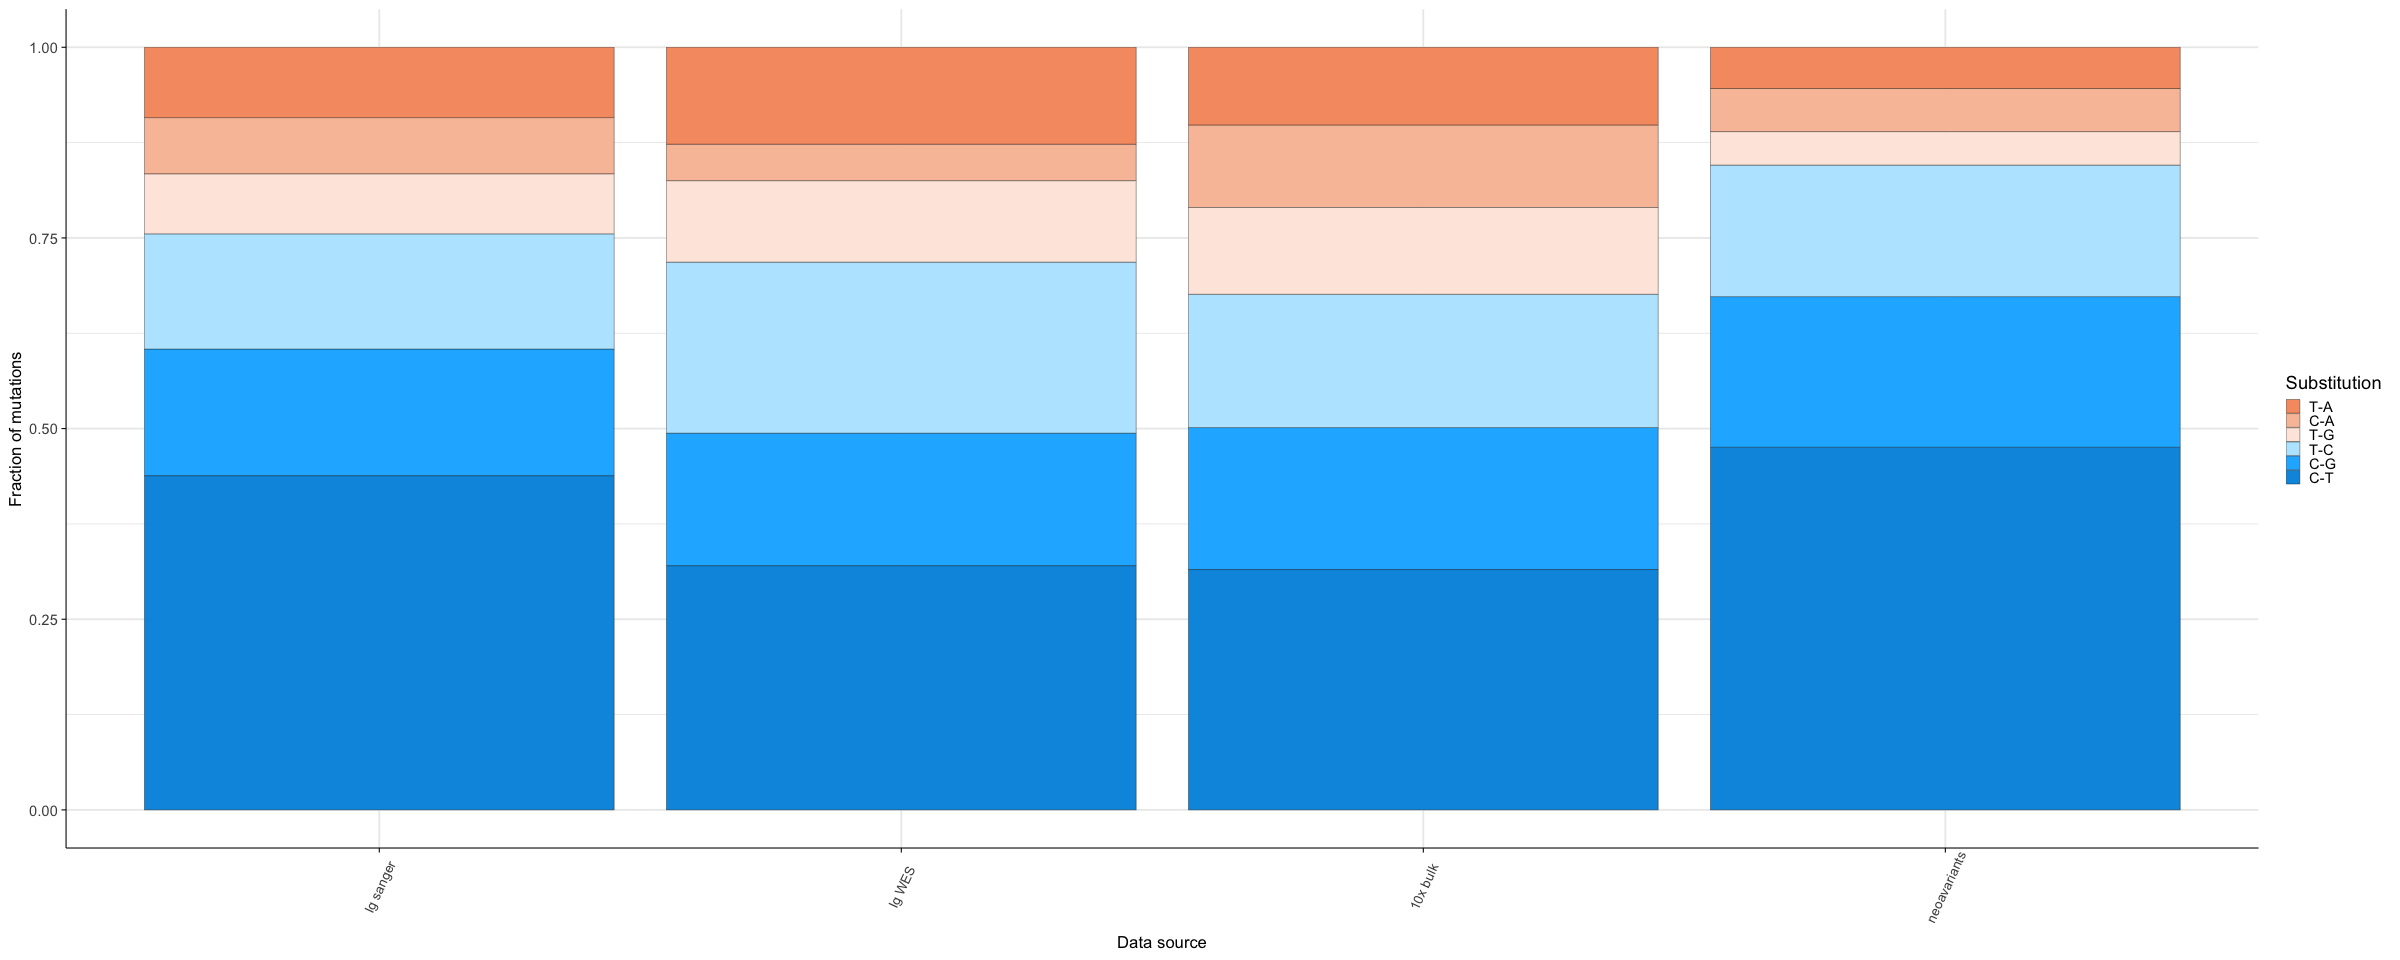

In [96]:
data <- spectro_combine

# Replace underscores in the 'source' labels
data$source <- gsub("_", " ", data$source)

# Reorder the 'substitution' factor according to your specified order for the plot
data$substitution <- factor(data$substitution, levels = c('T-A','C-A','T-G', 'T-C', 'C-G', 'C-T'))
data$source <- factor(data$source, levels = c('Ig sanger','Ig WES','10x bulk', 'neoavariants'))

# Calculate the total counts for each source
totals <- data %>%
  group_by(source) %>%
  summarize(Total_n = sum(total_n), .groups = 'drop')

# Create the stacked bar plot
p <- ggplot(data, aes(x = source, y = Percentage, fill = substitution)) +
  geom_bar(stat = "identity", position = "fill",color="black",linewidth=0.1) +
  #geom_text(data = totals, aes(x = source, label = Total_n), vjust = 0, nudge_y = max(data$Percentage) * 0.05) +
  scale_fill_manual(values = c("#f69b70", "#f9c2a7", "#fde8df", "#b9e8ff", "#1cb6ff", "#0098e0")) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 65, vjust = 0.6, size = 8), 
        axis.title = element_text(size = 10),
        plot.title = element_text(size = 12),
       axis.line = element_line(linewidt = 0.3, colour = "black", linetype=1),
       axis.ticks = element_line(size = 0.3, color="black"),
       legend.key.size = unit(0.3, 'cm')) +
  labs(x = "Data source", y = "Fraction of mutations", fill = "Substitution")



# Save the plot
#ggsave("figs_paper/substitution_spectrum_stacked_barplot.png", plot = p, width = 7, height = 7, units = "cm", dpi = 300)
#ggsave("figs_paper/substitution_spectrum_stacked_barplot.pdf", plot = p, width = 7, height = 7, units = "cm")

# Print the plot
print(p)


In [97]:
# function to perform chi-square test on each group
perform_chisq_test <- function(df) {
  chisq_result <- chisq.test(df$Percentage)$p.value
  return(data.frame(chisq_test_p_value = chisq_result))
}

# Perform the chi-square tests
chi_square_results <- spectro_combine %>% 
  filter(source %in% c("10x_bulk", "neoavariants")) %>% 
  group_by(substitution, source) %>% 
  group_by(substitution) %>% 
  nest() %>% 
  rowwise() %>% 
  summarise(perform_chisq_test(data))

# Print chi-square test results
print(chi_square_results)


`summarise()` has grouped output by 'substitution'. You can override using the
`.groups` argument.


# A tibble: 6 × 2
# Groups:   substitution [6]
  substitution chisq_test_p_value
  <chr>                     <dbl>
1 C-A                      0.204 
2 C-G                      0.855 
3 C-T                      0.0714
4 T-A                      0.226 
5 T-C                      0.969 
6 T-G                      0.0777


#### Data for Hendrik (substitution by subject)

In [98]:
spectro_10x <- KBall_subs_subject %>% bind_rows(spectro_subject)

In [99]:
spectro_10x <- spectro_10x %>% mutate(Patient_id = str_extract(subject, "S\\d+")) %>% group_by(Patient_id,source,substitution) %>%
  summarise(total_n=sum(n)) %>%  mutate(Percentage=total_n * 100 / sum(total_n))

`summarise()` has grouped output by 'Patient_id', 'source'. You can override
using the `.groups` argument.


In [100]:
head(spectro_10x)

Patient_id,source,substitution,total_n,Percentage
<chr>,<chr>,<chr>,<int>,<dbl>
S10000,10x_bulk,C-A,151,12.08
S10000,10x_bulk,C-G,251,20.08
S10000,10x_bulk,C-T,340,27.20
S10000,10x_bulk,T-A,153,12.24
S10000,10x_bulk,T-C,206,16.48
S10000,10x_bulk,T-G,149,11.92


In [101]:
# WriteXLS::WriteXLS(spectro_10x,
#                     "output/substitution_spectrum_10x.xlsx" )

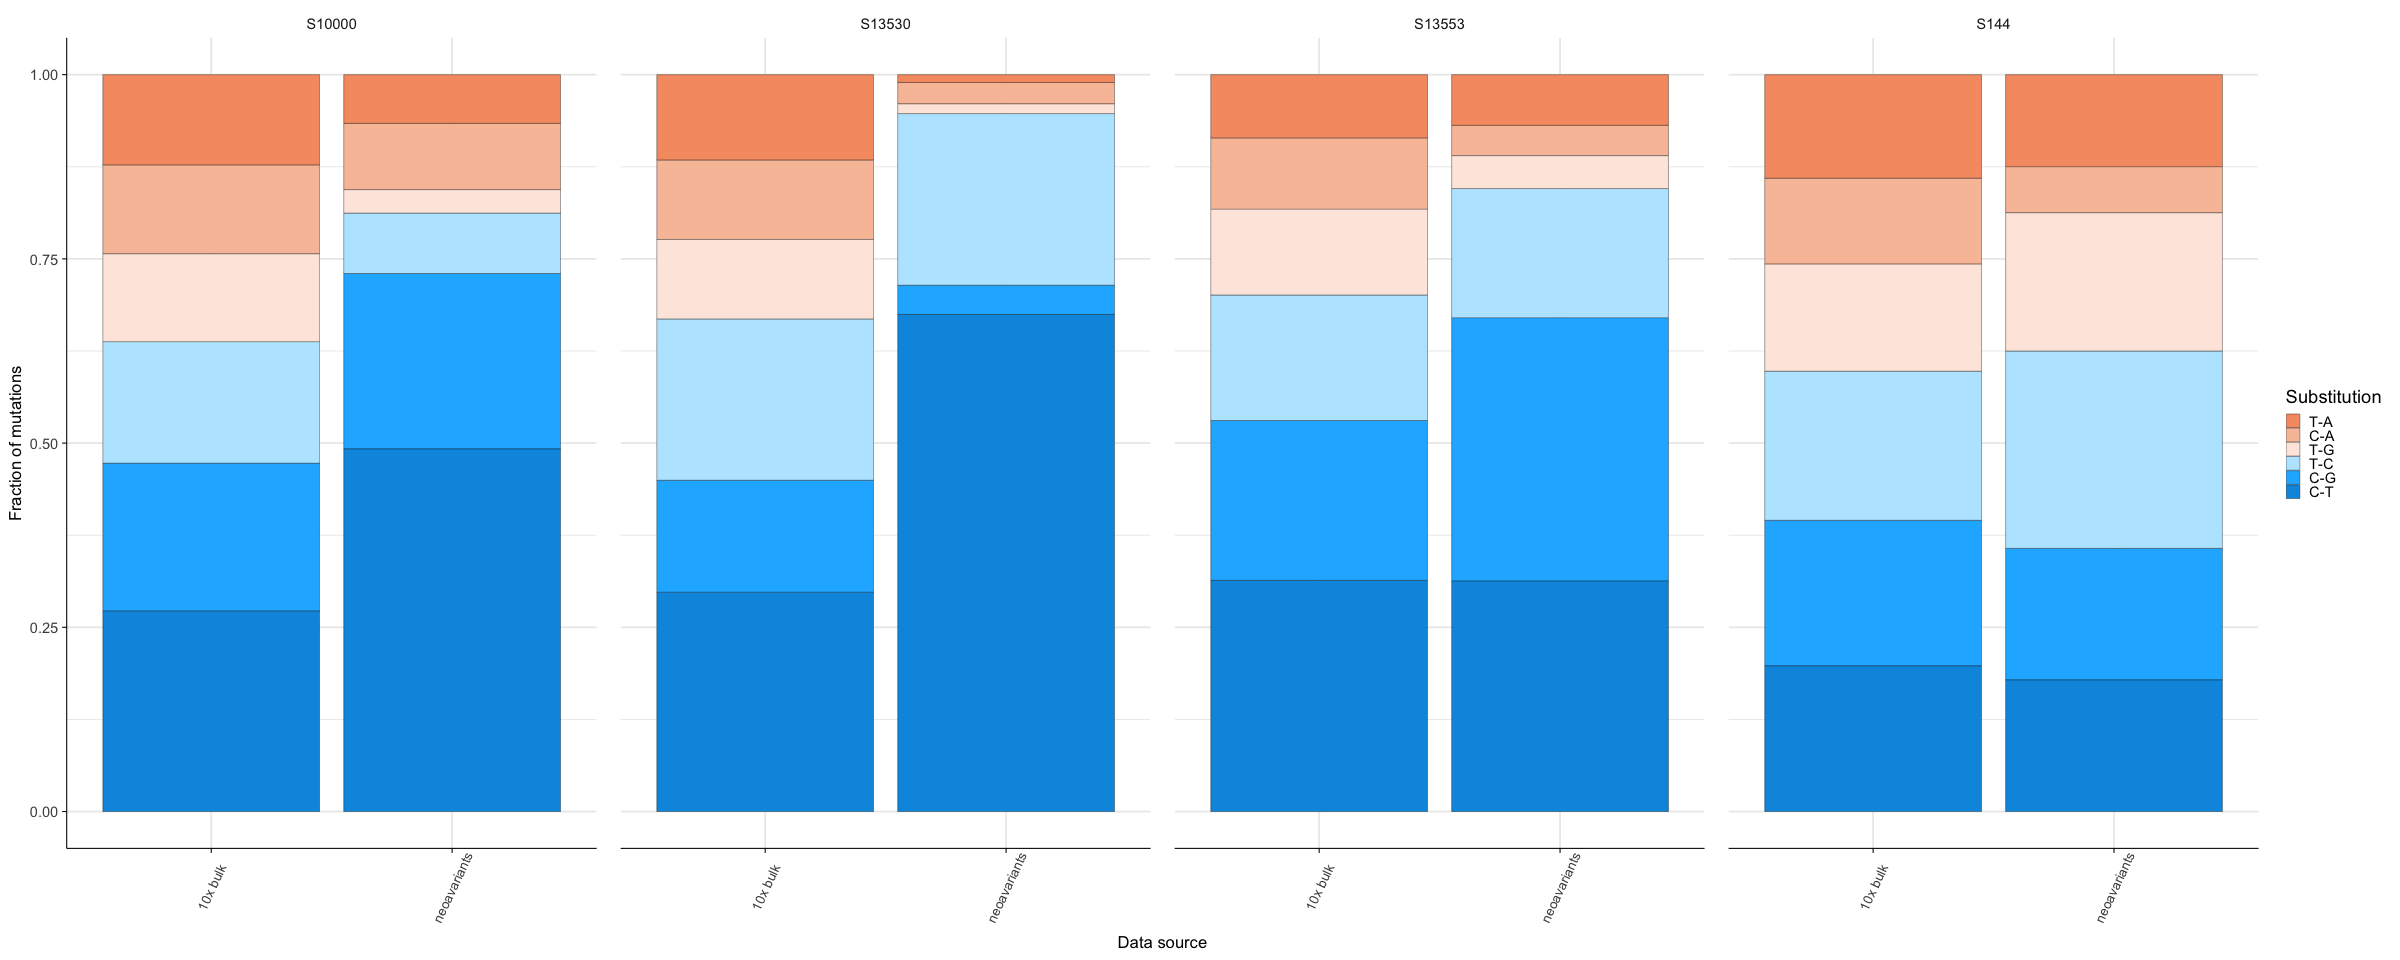

In [103]:
data <- spectro_10x

# Replace underscores in the 'source' labels
data$source <- gsub("_", " ", data$source)

# Reorder the 'substitution' factor according to your specified order for the plot
data$substitution <- factor(data$substitution, levels = c('T-A','C-A','T-G', 'T-C', 'C-G', 'C-T'))

# Calculate the total counts for each source
totals <- data %>%
  group_by(Patient_id) %>%
  summarize(Total_n = sum(total_n), .groups = 'drop')

# Create the stacked bar plot
p <- ggplot(data %>% filter(Patient_id %in% c("S10000","S13530","S13553", "S144")), aes(x = source, y = Percentage, fill = substitution)) +
  geom_bar(stat = "identity", position = "fill",color="black",linewidth=0.1) +
  #geom_text(data = totals, aes(x = source, label = Total_n), vjust = 0, nudge_y = max(data$Percentage) * 0.05) +
  scale_fill_manual(values = c("#f69b70", "#f9c2a7", "#fde8df", "#b9e8ff", "#1cb6ff", "#0098e0")) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 65, vjust = 0.6, size = 8), 
        axis.title = element_text(size = 10),
        plot.title = element_text(size = 12),
       axis.line = element_line(linewidt = 0.3, colour = "black", linetype=1),
       axis.ticks = element_line(size = 0.3, color="black"),
       legend.key.size = unit(0.3, 'cm'),
       panel.spacing = unit(1, "lines")) +
  labs(x = "Data source", y = "Fraction of mutations", fill = "Substitution") +
  facet_grid(. ~ Patient_id)



# Save the plot
#ggsave("figs_paper/substitution_spectrum_stacked_barplot.png", plot = p, width = 7, height = 7, units = "cm", dpi = 300)
ggsave("figs_paper/substitution_spectrum_stacked_barplot_subject.pdf", plot = p, width = 10.5, height = 7, units = "cm")

# Print the plot
print(p)


## 8. Calculate combinations of variants

In [3]:
events_v31 <- readxl::read_xlsx("output/events.v3.1.xlsx")

In [4]:
#Filter events in CD3 and FR4
df_umis <- read_csv("output/df_umis.csv") 

Rows: 84246 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): cell, umi, cons_nucl, nucl, context, region, nucl_po, context_po, ...
dbl  (4): position, depth, vgene_position, vgene_position_aligned
lgl  (1): productive

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
real_pos <- df_summary %>% filter(!subregion %in% c("CDR3", "FR4")) %>% select(subject, cell,position)

In [6]:
df_umis_filter <- df_umis %>% inner_join(real_pos, by=c("subject", "cell", "position"))

In [7]:
# Your existing script
df_combinations <- df_umis_filter %>%
  unite("position_nucl", c("position", "nucl"), sep = ":", remove = FALSE) %>%
  unite("position_nucl_po", c("position", "nucl_po"), sep = ":", remove = FALSE) %>%
  group_by(subject, cell, umi) %>%
 summarise(nucl_combination = toString(position_nucl),nucl_combination_po = toString(position_nucl_po), .groups = 'drop') %>%
  ungroup()

# Calculate the number of positions in each nucl_combination
df_combinations <- df_combinations %>%
  mutate(position_count = str_count(nucl_combination, pattern = ",") + 1)

# Calculate the count of distinct UMIs for each nucl_combination in each cell
df_combinations <- df_combinations %>%
  group_by(subject, cell, nucl_combination) %>%
  mutate(umi_count = n_distinct(umi)) %>%
  ungroup()

# Determine the maximum number of positions for each cell
max_positions_per_cell <- df_combinations %>%
  group_by(subject, cell) %>%
  summarise(max_positions = max(position_count)) %>%
  ungroup()

# Filter to only include nucl_combinations with the max amount of positions and more than one position
df_filtered <- df_combinations %>%
  inner_join(max_positions_per_cell, by = c("subject", "cell")) %>%
  filter(position_count == max_positions, position_count > 1) %>% select(-umi,-max_positions) %>% unique()


`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


In [8]:
# Assuming df_filtered is your current dataframe from the previous steps

# Count the number of unique nucl_combination for each cell
df_cell_combination_counts <- df_filtered %>%
  group_by(subject, cell) %>%
  summarise(unique_combinations = n_distinct(nucl_combination)) %>%
  ungroup()

# Filter for cells with more than two unique nucl_combination
df_cells_with_multiple_combinations <- df_filtered %>%
  inner_join(df_cell_combination_counts, by = c("subject", "cell")) %>%
  filter(unique_combinations > 2)


`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


In [9]:
# Identify the groups "Neo", "PO" and "PO-Neo"
df_umi_combination <- df_cells_with_multiple_combinations %>% 
  mutate(
   group = mapply(function(nucl, nucl_po) {
      # Split the strings into individual components
      nucl_split <- strsplit(nucl, ", ")[[1]]
      nucl_po_split <- strsplit(nucl_po, ", ")[[1]]

      # Ensure that both vectors have the same length
      if (length(nucl_split) != length(nucl_po_split)) {
        return(NA)
      }

      # Count matches and mismatches
      matches <- sum(nucl_split == nucl_po_split)
      mismatches <- length(nucl_split) - matches

      # Determine the category based on counts
      if (matches == length(nucl_split)) {
        return("PO")
      } else if (mismatches == length(nucl_split)) {
        return("Neo")
      } else {
        return("PO-Neo")
      }
    }, nucl_combination, nucl_combination_po)
  )

In [10]:
df_umi_combination <- df_umi_combination %>%
  group_by(subject, cell) %>%
  # Check if both PO and Neo are present
  mutate(both_po_neo_present = all(c("PO", "Neo") %in% unique(group))) %>%
  # Order by umi_count within each group and get the top two group names
  arrange(desc(umi_count)) %>%
  mutate(top_two_groups = list(head(unique(group), 2))) %>%
  # Check if the top two groups are PO and Neo
  mutate(is_expected = both_po_neo_present & all(c("PO", "Neo") %in% top_two_groups[[1]])) %>%
  # Assign type based on the condition
  mutate(type = if_else(is_expected, "expected", "unexpected")) %>%
  # Optionally, remove the helper columns
  select(-both_po_neo_present, -top_two_groups, -is_expected)

# View the result
head(df_umi_combination)

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>
K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:T, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,105,3,PO-Neo,unexpected
K6B_S13530-LC,CGGAGCTAGATCACGG,"122:A, 196:C, 278:T, 306:T, 207:A, 187:T, 192:C","122:G, 196:C, 278:T, 306:C, 207:A, 187:T, 192:C",7,104,4,PO-Neo,unexpected
K6B_S13530-LC,GTGCGGTAGGCGACAT,"207:A, 184:A","207:A, 184:C",2,90,3,PO-Neo,unexpected
K6B_S13530-LC,TGTGGTAGTACCATCA,"306:C, 196:T, 207:G","306:C, 196:C, 207:A",3,86,3,PO-Neo,unexpected
K6B_S13530-HC,AGTGTCAAGAGGTTAT,"255:C, 379:G","255:C, 379:G",2,77,3,PO,expected
K7B_S10000-LC,AACACGTCAGCTGGCT,"185:A, 213:A, 228:A","185:G, 213:A, 228:G",3,66,3,PO-Neo,unexpected


In [11]:
# Assuming df is your data frame
df_umi_combination_w <- df_umi_combination %>%
  group_by(subject, cell) %>%
  mutate(
    highest_umi_count = umi_count == max(umi_count)
  ) %>%
  ungroup()

# Function to check if two combinations are completely different
all_positions_different <- function(comb1, comb2) {
  positions1 <- unlist(strsplit(comb1, ", "))
  positions2 <- unlist(strsplit(comb2, ", "))
  all(mapply(function(p1, p2) substr(p1, nchar(p1), nchar(p1)) != substr(p2, nchar(p2), nchar(p2)), positions1, positions2))
}

# Apply the function to compare nucl_combinations
df_umi_combination_wa  <- df_umi_combination_w  %>%
  group_by(subject, cell) %>%
  mutate(
    alternative_type = case_when(
      highest_umi_count ~ "highest_umi_count",
      sapply(nucl_combination, function(nc) all_positions_different(nc, nucl_combination[highest_umi_count])) ~ "all positions alternative",
      TRUE ~ "partial alternative"
    )
  ) %>%
  ungroup()

# Ranking umi_count only for partial alternatives
df_umi_combination_wa  <- df_umi_combination_wa  %>%
  group_by(subject, cell, alternative_type) %>%
  mutate(
    umi_rank = ifelse(alternative_type == "partial alternative", rank(-umi_count), NA_integer_)
  ) %>%
  ungroup()

# Updating alternative_type with rank
df_umi_combination_wat  <- df_umi_combination_wa  %>%
  mutate(
    alternative_type = ifelse(!is.na(umi_rank), paste("partial alternative", umi_rank), alternative_type)
  )



In [12]:

# Assuming df is your data frame
df_umi_combination_w <- df_umi_combination %>%
  group_by(subject, cell) %>%
  mutate(
    highest_umi_count = umi_count == max(umi_count)
  ) %>%
  ungroup()

# Function to check if two combinations are completely different
all_positions_different <- function(comb1, comb2) {
  positions1 <- unlist(strsplit(comb1, ", "))
  positions2 <- unlist(strsplit(comb2, ", "))
  all(mapply(function(p1, p2) substr(p1, nchar(p1), nchar(p1)) != substr(p2, nchar(p2), nchar(p2)), positions1, positions2))
}

# Apply the function to compare nucl_combinations
df_umi_combination_w <- df_umi_combination_w %>%
  group_by(subject, cell) %>%
  mutate(
    alternative_type = case_when(
      highest_umi_count ~ "highest_umi_count",
      sapply(nucl_combination, function(nc) all_positions_different(nc, nucl_combination[highest_umi_count])) ~ "all positions alternative",
      TRUE ~ "partial alternative"
    )
  ) %>%
  ungroup()

# Separate partial alternatives and rank them
partial_alternatives <- df_umi_combination_w %>%
  filter(alternative_type == "partial alternative") %>%
  group_by(subject, cell) %>%
  arrange(desc(umi_count)) %>%
  mutate(alternative_rank = row_number()) %>%
  ungroup()

# Merge the ranked partial alternatives back into the main dataframe
df_umi_combination_wa <- df_umi_combination_w %>%
  left_join(partial_alternatives %>% select(subject, cell, nucl_combination, alternative_rank), by = c("subject", "cell", "nucl_combination")) %>%
  mutate(
    alternative_type = ifelse(alternative_type == "partial alternative" & !is.na(alternative_rank),
                              paste("partial alternative", alternative_rank),
                              alternative_type)
  ) %>%
  select(-alternative_rank,-highest_umi_count)  # Optional: remove the helper column


In [13]:
# Function to compare two nucleotide combinations
compare_combinations <- function(comb1, comb2) {
  # Split the combinations into individual positions
  positions1 <- strsplit(comb1, ", ")[[1]]
  positions2 <- strsplit(comb2, ", ")[[1]]
  
  # Compare the positions
  matches <- mapply(function(p1, p2) p1 == p2, positions1, positions2)
  
  # Calculate percentage of match
  percent_match <- sum(matches) / length(matches) * 100
  return(percent_match)
}

# Applying the function to the dataframe
df_umi_combination_wat <- df_umi_combination_wa %>%
  rowwise() %>%
  mutate(
    match_percentage_po = compare_combinations(nucl_combination, nucl_combination_po)
  ) %>%
  ungroup()


In [35]:
#Updating labeling for plotting
df_umi_combination_wate <- df_umi_combination_wat %>%
  group_by(subject, cell) %>%
  mutate(
    highest_count = sum(alternative_type == "highest_umi_count"),
    label = case_when(
      highest_count == 2 & alternative_type == "highest_umi_count" & match_percentage_po > 50 ~ "Highest",
      highest_count == 2 & alternative_type == "highest_umi_count" & group != "PO" ~ "Opposite",
      highest_count != 2 & alternative_type == "highest_umi_count" ~ "Highest",
      alternative_type == "all positions alternative" ~ "Opposite",
      TRUE ~ as.character(alternative_type)  # Keep current label or assign a default
    )
  )   %>%
  group_by(subject,cell) %>%
  mutate(total_umi = sum(umi_count),
         umi_percentage = (umi_count / total_umi) * 100)
# Create a column for subject type identifier (HC or LC)
df_umi_combination_wate$subject_type <- ifelse(grepl("HC$", df_umi_combination_wate$subject), "HC", "LC")


In [36]:
df <- df_umi_combination_wate

In [37]:
#Which cells do not have Hightest and opposite

# Group the data by 'subject' and 'cell'
groups <- df %>%
  group_by(subject, cell) %>%
  summarise(alternative_types = list(unique(label)))

# Check that each group has both 'Highest' and 'Opposite'
verification <- groups %>%
  rowwise() %>%
  mutate(contains_both = all(c("Highest", "Opposite") %in% alternative_types)) %>%
  ungroup()

# Verify if all groups have both 'Highest' and 'Opposite'
all_groups_have_both <- all(verification$contains_both)

# If not all groups have both, show which do not
groups_without_both <- verification %>%
  filter(!contains_both)

# You can view the results with
print(all_groups_have_both)
print(groups_without_both)

#Conclusion: 4 of them have only highest and not opposite, which is comething that can happens, but one of them "GGGAGATAGGACTGGT", it is possibke to define which one is the hightest

`summarise()` has grouped output by 'subject'. You can override using the
`.groups` argument.


[1] FALSE
# A tibble: 6 × 4
  subject       cell             alternative_types contains_both
  <chr>         <chr>            <list>            <lgl>        
1 K6B_S13530-HC TTGGCAAGTTTGGCGC <chr [3]>         FALSE        
2 K6B_S13530-LC GGGAGATAGGACTGGT <chr [2]>         FALSE        
3 K6B_S13530-LC TTGCCGTGTCTCTCTG <chr [6]>         FALSE        
4 K7B_S10000-LC CGTTGGGTCCTTTCTC <chr [4]>         FALSE        
5 K7B_S10000-LC TAGTGGTCATCTCCCA <chr [3]>         FALSE        
6 K8B_S13553-LC CTAGCCTGTCTTCGTC <chr [3]>         FALSE        


In [38]:
#Case one highest and none opposite: this cell has a odd pattern when I check the image, I think should be discarted
df %>% arrange(subject,cell) %>% filter(cell == "TTGGCAAGTTTGGCGC")

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<chr>
K6B_S13530-HC,TTGGCAAGTTTGGCGC,"367:C, 145:G","367:C, 145:G",2,27,3,PO,unexpected,highest_umi_count,100,1,Highest,46,58.69565,HC
K6B_S13530-HC,TTGGCAAGTTTGGCGC,"367:T, 145:G","367:C, 145:G",2,10,3,PO-Neo,unexpected,partial alternative 1,50,1,partial alternative 1,46,21.73913,HC
K6B_S13530-HC,TTGGCAAGTTTGGCGC,"367:C, 145:A","367:C, 145:G",2,9,3,PO-Neo,unexpected,partial alternative 2,50,1,partial alternative 2,46,19.56522,HC


In [39]:
#Case one highest and none opposite: this cell has a odd pattern when I check the image, I think should be discarted
df %>% arrange(subject,cell) %>% filter(cell == "TTGCCGTGTCTCTCTG")

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<chr>
K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:G, 187:C, 207:A","122:G, 187:T, 207:A",3,17,6,PO-Neo,unexpected,highest_umi_count,66.66667,1,Highest,55,30.909091,LC
K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:G, 187:C, 207:G","122:G, 187:T, 207:A",3,16,6,PO-Neo,unexpected,partial alternative 1,33.33333,1,partial alternative 1,55,29.090909,LC
K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:A, 187:T, 207:A","122:G, 187:T, 207:A",3,10,6,PO-Neo,unexpected,partial alternative 2,66.66667,1,partial alternative 2,55,18.181818,LC
K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:G, 187:T, 207:G","122:G, 187:T, 207:A",3,6,6,PO-Neo,unexpected,partial alternative 3,66.66667,1,partial alternative 3,55,10.909091,LC
K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:G, 187:T, 207:A","122:G, 187:T, 207:A",3,3,6,PO,unexpected,partial alternative 4,100.00000,1,partial alternative 4,55,5.454545,LC
K6B_S13530-LC,TTGCCGTGTCTCTCTG,"122:A, 187:C, 207:G","122:G, 187:T, 207:A",3,3,6,Neo,unexpected,partial alternative 5,0.00000,1,partial alternative 5,55,5.454545,LC


In [40]:
df_summary %>% filter(cell == "TTGGCAAGTTTGGCGC")

X,subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive,aid_motif1,aid_motif2,position
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
163,K6B_S13530-HC,TTGGCAAGTTTGGCGC,9,G,CA.CT,FR1,A-G,10-39,TRUE,WA,WRCY,145
285,K6B_S13530-HC,TTGGCAAGTTTGGCGC,231,C,AA.TC,FR3,C-T,36-10,TRUE,WRCY,WA,367


In [41]:
df %>% arrange(subject,cell)#filter(cell == "TGTGGTAGTACCATCA")

subject,cell,nucl_combination,nucl_combination_po,position_count,umi_count,unique_combinations,group,type,alternative_type,match_percentage_po,highest_count,label,total_umi,umi_percentage,subject_type
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<int>,<dbl>,<chr>
K6B_S13530-HC,ACTGAGTCAATCTACG,"367:C, 291:C, 262:A, 317:T","367:C, 291:G, 262:G, 317:G",4,47,3,PO-Neo,unexpected,highest_umi_count,25.00000,1,Highest,72,65.2777778,HC
K6B_S13530-HC,ACTGAGTCAATCTACG,"367:T, 291:G, 262:G, 317:G","367:C, 291:G, 262:G, 317:G",4,24,3,PO-Neo,unexpected,all positions alternative,75.00000,1,Opposite,72,33.3333333,HC
K6B_S13530-HC,ACTGAGTCAATCTACG,"367:C, 291:G, 262:G, 317:G","367:C, 291:G, 262:G, 317:G",4,1,3,PO,unexpected,partial alternative 1,100.00000,1,partial alternative 1,72,1.3888889,HC
K6B_S13530-HC,AGTGTCAAGAGGTTAT,"255:C, 379:G","255:C, 379:G",2,77,3,PO,expected,highest_umi_count,100.00000,1,Highest,114,67.5438596,HC
K6B_S13530-HC,AGTGTCAAGAGGTTAT,"255:T, 379:A","255:C, 379:G",2,36,3,Neo,expected,all positions alternative,0.00000,1,Opposite,114,31.5789474,HC
K6B_S13530-HC,AGTGTCAAGAGGTTAT,"255:C, 379:A","255:C, 379:G",2,1,3,PO-Neo,expected,partial alternative 1,50.00000,1,partial alternative 1,114,0.8771930,HC
K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:T, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,105,3,PO-Neo,unexpected,highest_umi_count,20.00000,1,Highest,159,66.0377358,HC
K6B_S13530-HC,AGTTGGTTCTGATACG,"291:G, 255:C, 261:A, 367:C, 400:A","291:G, 255:C, 261:G, 367:C, 400:C",5,53,3,PO-Neo,unexpected,all positions alternative,60.00000,1,Opposite,159,33.3333333,HC
K6B_S13530-HC,AGTTGGTTCTGATACG,"291:C, 255:T, 261:G, 367:C, 400:G","291:G, 255:C, 261:G, 367:C, 400:C",5,1,3,PO-Neo,unexpected,partial alternative 1,40.00000,1,partial alternative 1,159,0.6289308,HC


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


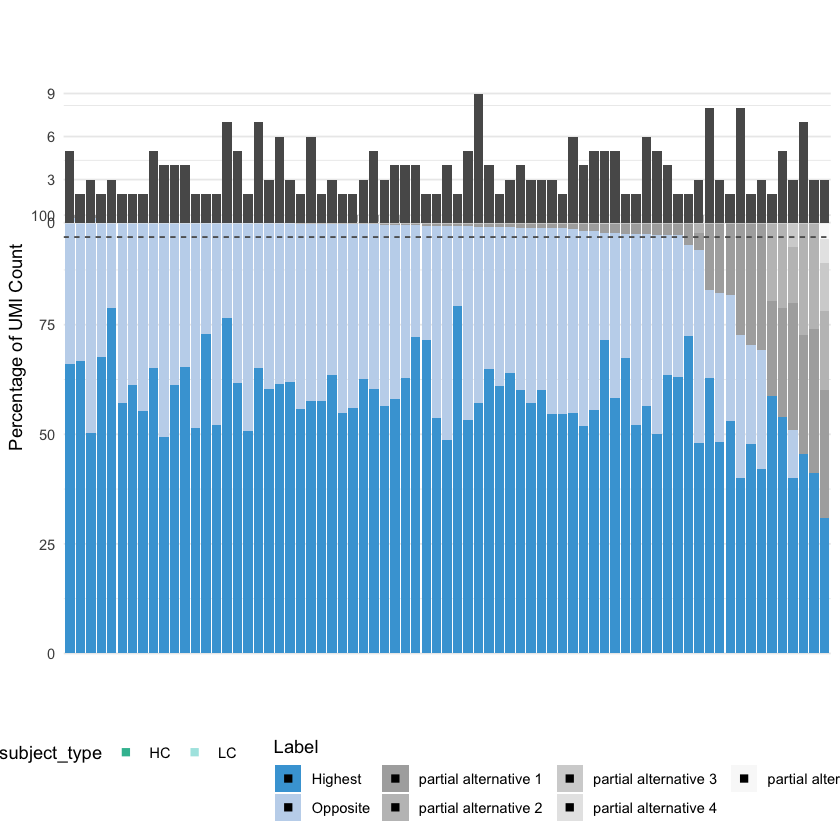

In [45]:
# Provided color codes
panel_A_colors <- c("#f69b70", "#f9c2a7", "#fde8df", "#b9e8ff", "#1cb6ff", "#0098e0")
panel_B_colors <- c( "#d3d3d3", "#3ac5a4", "#3c90be", "#394abe")

# Select distinct colors for "Highest" and "Opposite"
highest_color <- "#46a4d8" # A strong blue
opposite_color <- "#c2d6ed"   

# Select a base color for the "partialalt" labels and generate shades

partialalt_shades <- colorRampPalette(c("#adadad", "#f9f9f9"))(5)  # Assuming 4 partialalt labels

# Define the custom color palette
custom_colors <- c("Highest" = highest_color, "Opposite" = opposite_color, 
                   setNames(partialalt_shades, paste("partial alternative", 1:5)))

# Define colors for HC and LC
hc_lc_colors <- c("HC" = "#39bc9f", "LC" = "#ace6e3")

# Assuming your data frame is named df
# Add subject_type_color column based on the 'subject' ending
df <- df  %>% filter(!cell == "GGGAGATAGGACTGGT") %>%
   mutate(cell_chain=paste0(cell,"_",subject_type))

summarized_data <- df %>% 
  group_by(cell_chain) %>%
  filter(label == "Highest" | label == "Opposite") %>%
  summarise(total_umi = sum(umi_percentage)) %>%
  arrange(desc(total_umi))

# Adjust the levels of the factor for 'cell' based on 'total_umi'
df$cell_chain <- factor(df$cell_chain, levels = summarized_data$cell_chain)

# Create the plot
ggplot_object <- ggplot(df, aes(x = cell_chain, y = umi_percentage, fill = label)) + #reorder(cell, cell_order)
  geom_bar(stat = "identity", position=position_stack(reverse = TRUE)) +
  scale_fill_manual(values = custom_colors) +
  geom_point(data = df, aes(x = cell_chain, y = 102, color = subject_type), 
             size = 2, shape = 15) +  # Using square shape for the points
  scale_color_manual(values = hc_lc_colors) +
  labs(x = "", y = "Percentage of UMI Count") +
  theme_minimal() +
  theme(axis.text.x = element_blank(),
        legend.position = "bottom",
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank()) +
  guides(fill = guide_legend(title = "Label", title.position = "top")) +
  scale_y_continuous(limits = c(0, 140), breaks = seq(0, 124, by = 25)) +
  geom_hline(yintercept = 95, linetype = "33", color = "#595959") 

# Calculate the summary for position_count
summary_position_count <- df %>%
  group_by(cell_chain) %>%
  summarise(avg_position_count = mean(position_count))  # or use sum, max, etc.

# Adjust the levels of the factor for 'cell' based on 'total_umi'
summary_position_count$cell_chain <- factor(summary_position_count$cell_chain, levels = summarized_data$cell_chain)

small_plot <- ggplot(summary_position_count, aes(x = cell_chain, y = avg_position_count)) +
  geom_bar(stat = "identity") +
   scale_y_continuous(limits = c(0, 10), 
                     breaks = seq(0, 10, by = 5)) +  # Adjust y-axis limits and expansion
  theme_minimal() +  # Use a minimal theme as a base
  theme(
    axis.title.x = element_blank(),  # Remove x-axis title
    axis.title.y = element_blank(),
    axis.text.x = element_blank(),  # Remove x-axis text
    axis.ticks.x = element_blank(),  # Remove x-axis ticks
    plot.margin = margin(1, 0, 1, -0.35, "cm"),
            panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
  panel.grid.major.y = element_line(),  # Remove major y-axis grid lines
    panel.grid.minor.y = element_blank()  # Remove minor y-axis grid lines
) +  scale_y_continuous(limits = c(0, max(summary_position_count$avg_position_count)),  # Set y-axis limits dynamically
                     breaks = seq(0, max(summary_position_count$avg_position_count), 3))   # More breaks on y-axis

# Create a grob (graphic object) from the small plot
small_grob <- ggplotGrob(small_plot)

# Embed the small plot on top of the main plot
ggplot_object <- ggplot_object +
  annotation_custom(grob = small_grob, xmin = -Inf, xmax = Inf, ymin = 85, ymax = 140) 

# Print the plot
print(ggplot_object)

#ggsave("figs_paper/umi_combination.pdf", plot = ggplot_object, width = 17.5, height = 12, units = "cm")

In [47]:

# Function to split the combination into position-letter pairs
split_combination <- function(combination) {
  str_split(combination, ",\\s*")[[1]] %>%
    map(~str_split(., ":")[[1]][2])  # Extract only the nucleotide letters
}

# Function to compare combinations and count matches
compare_and_count_matches <- function(highest_comb, other_comb) {
  # Split into position-letter pairs
  highest_pairs <- split_combination(highest_comb)
  other_pairs <- split_combination(other_comb)

  # Count matches
  sum(mapply(`==`, highest_pairs, other_pairs))
}

# Process the data
comparison_results <- df %>%
  group_by(subject, cell) %>%
  filter(any(label == "Highest")) %>%
  reframe(
    highest_combination = nucl_combination[label == "Highest"][1],
    other_combination = c(nucl_combination[label == "Highest"][1], nucl_combination[label != "Highest"]),
            unique_combinations = unique_combinations[label == "Highest"],
    match_count = c(length(split_combination(nucl_combination[label == "Highest"][1])), 
                    map_int(nucl_combination[label != "Highest"], 
                            ~compare_and_count_matches(nucl_combination[label == "Highest"][1], .))),
    position_count = position_count[label == "Highest"],  # Retain position_count for the 'Highest'
      umi_percentage = umi_percentage,
      cell_chain=cell_chain
  ) %>%
  ungroup()

In [48]:
# View the results
comparison_results <- comparison_results %>% mutate(ummatch = (position_count-match_count)*1/position_count) 
head(comparison_results)

subject,cell,highest_combination,other_combination,unique_combinations,match_count,position_count,umi_percentage,cell_chain,ummatch
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<fct>,<dbl>
K6B_S13530-HC,ACTGAGTCAATCTACG,"367:C, 291:C, 262:A, 317:T","367:C, 291:C, 262:A, 317:T",3,4,4,65.277778,ACTGAGTCAATCTACG_HC,0.00
K6B_S13530-HC,ACTGAGTCAATCTACG,"367:C, 291:C, 262:A, 317:T","367:T, 291:G, 262:G, 317:G",3,0,4,33.333333,ACTGAGTCAATCTACG_HC,1.00
K6B_S13530-HC,ACTGAGTCAATCTACG,"367:C, 291:C, 262:A, 317:T","367:C, 291:G, 262:G, 317:G",3,1,4,1.388889,ACTGAGTCAATCTACG_HC,0.75
K6B_S13530-HC,AGTGTCAAGAGGTTAT,"255:C, 379:G","255:C, 379:G",3,2,2,67.543860,AGTGTCAAGAGGTTAT_HC,0.00
K6B_S13530-HC,AGTGTCAAGAGGTTAT,"255:C, 379:G","255:T, 379:A",3,0,2,31.578947,AGTGTCAAGAGGTTAT_HC,1.00
K6B_S13530-HC,AGTGTCAAGAGGTTAT,"255:C, 379:G","255:C, 379:A",3,1,2,0.877193,AGTGTCAAGAGGTTAT_HC,0.50


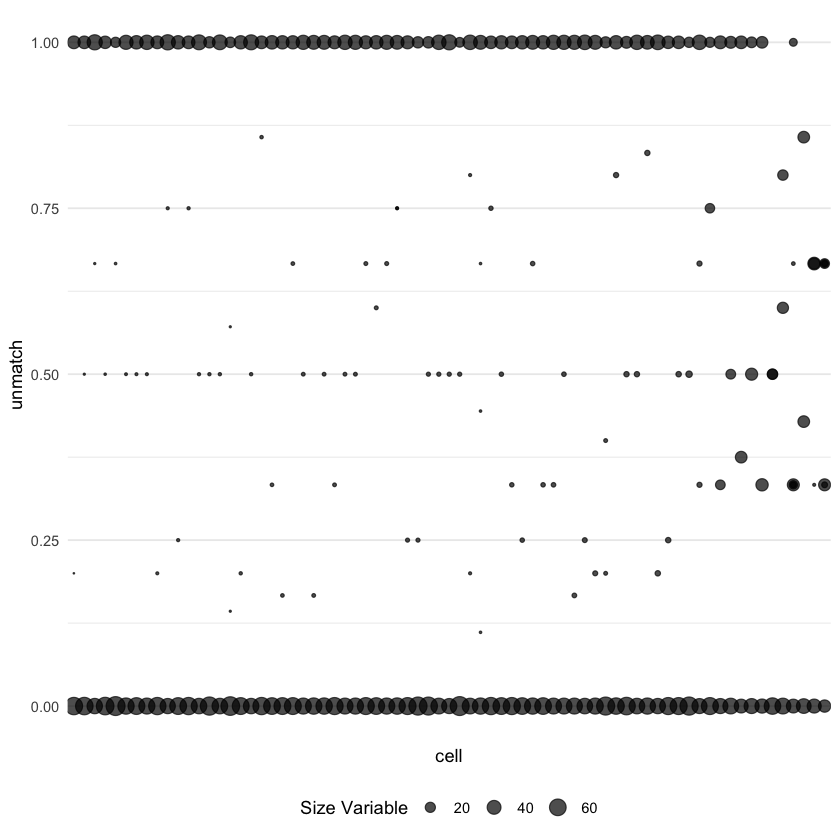

In [49]:

# Sample code for creating a dot plot
ggplot_object <- ggplot(comparison_results, aes(x = cell_chain, y = ummatch, size = umi_percentage)) +
  geom_point(alpha = 0.7) +  # Adjust alpha for dot transparency if needed
  scale_size_continuous(name = "Size Variable", range = c(0.1, 5)) +  # Adjust the size range as needed
  labs(x = "cell", y = "unmatch") +
    theme_minimal() +
  theme(axis.text.x = element_blank(),
        legend.position = "bottom",
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank()) 

# Print the plot
print(ggplot_object)


ggsave("figs_paper/umi_combination_dotplot.pdf", plot = ggplot_object, width = 17.5, height = 7, units = "cm")

In [50]:
# new visualization

result <- df %>% group_by(cell_chain) %>%   summarize(
    sum_umi_percentage = sum(umi_percentage[(label == "Highest" | label == "Opposite")], na.rm = TRUE)
  )
head(result)

cell_chain,sum_umi_percentage
<fct>,<dbl>
AGTTGGTTCTGATACG_HC,99.37107
GTGCGGTAGGCGACAT_LC,99.25926
AACACGTCAGCTGGCT_LC,99.23664
AGTGTCAAGAGGTTAT_HC,99.12281
TGTGGTAGTACCATCA_LC,99.08257
CGTAGGCAGCGCTCCA_HC,98.90110


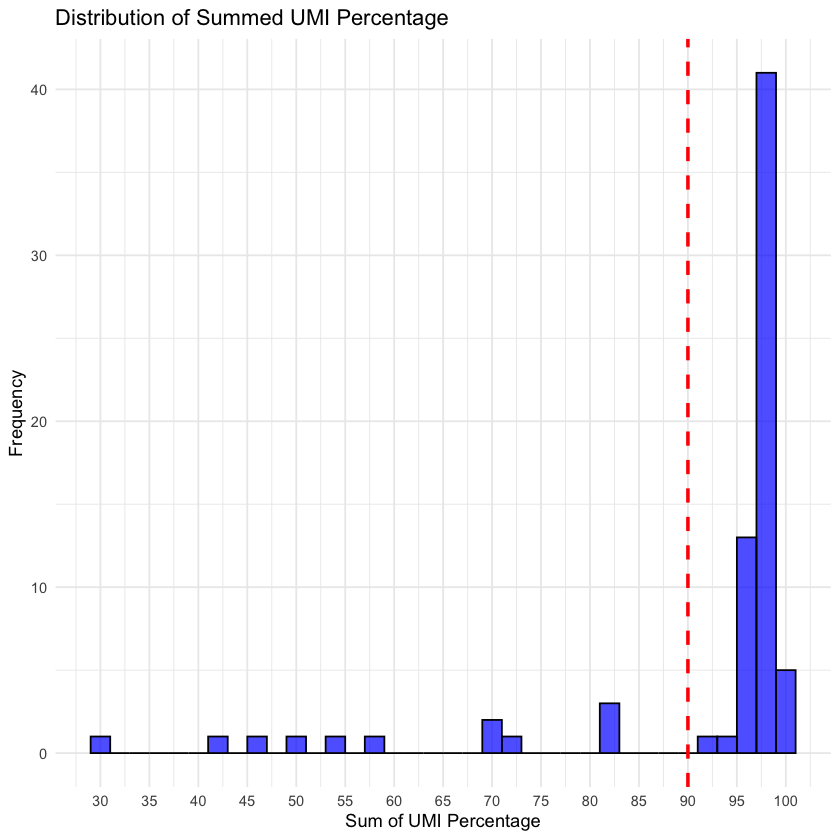

In [51]:

# Creating the plot
dis <- ggplot(result, aes(x = sum_umi_percentage)) +
  geom_histogram(binwidth = 2, fill = "blue", color = "black", alpha = 0.7) + # or geom_density() for a density plot
  geom_vline(xintercept = 90, color = "red", linetype = "dashed", size = 1) +
#geom_text(data = annotations, aes(x = midpoint, y = count, label = count), vjust = -0.5) +
  theme_minimal() +
  labs(title = "Distribution of Summed UMI Percentage",
       x = "Sum of UMI Percentage",
       y = "Frequency") +
scale_x_continuous(breaks = seq(30,100, by = 5))

dis
ggsave("figs_paper/umi_combination_distribution.pdf", plot = dis, width = 10, height = 7, units = "cm")

#### New PO classification

In [52]:
# Step 1: Identify groups with at least 'Highest' and 'Opposite' labels
valid_groups <- df %>%
  group_by(subject, cell) %>%
  filter(any(label == "Highest") & any(label == "Opposite")) %>%
  ungroup() %>%
  distinct(subject, cell)

# Step 2, 3, 4, and 5: Categorize each row
df <- df %>%
  rowwise() %>%
  mutate(categorized_label = if_else(
    (subject %in% valid_groups$subject) & (cell %in% valid_groups$cell),
    if_else(
      label %in% c("Highest", "Opposite"),
      {
        # Find the max match_percentage_po for 'Highest' and 'Opposite'
        max_po_highest <- max(df$match_percentage_po[df$subject == subject & df$cell == cell & df$label == "Highest"], na.rm = TRUE)
        max_po_opposite <- max(df$match_percentage_po[df$subject == subject & df$cell == cell & df$label == "Opposite"], na.rm = TRUE)

        if (max_po_highest == max_po_opposite && max_po_highest == 50) {
          "Undetermined"
        } else if (label == "Highest" && max_po_highest >= max_po_opposite) {
          "PO"
        } else if (label == "Opposite" && max_po_opposite > max_po_highest) {
          "PO"
        } else {
          "Neovariant"
        }
      },
      NA_character_
    ),
    "unvalid"
  ))

Warning message:
“There were 19 warnings in `mutate()`.
The first warning was:
ℹ In argument: `categorized_label = if_else(...)`.
ℹ In row 36.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 18 remaining warnings.”


In [80]:
# Pivoting the data into a wide format

df <- df %>% group_by(subject, cell) %>%
  filter(!is.na(categorized_label), label %in% c("Highest", "Opposite")) %>%
  mutate(index = row_number()) %>%
  ungroup()

df_wide <- df %>% filter(!is.na(categorized_label)) %>% select(subject,cell,nucl_combination_po,nucl_combination,match_percentage_po,categorized_label,index) %>% 
  pivot_wider(
    id_cols = c(subject, cell,nucl_combination_po),
    names_from = index,
    names_sep = "",
    values_from = c(nucl_combination, categorized_label, match_percentage_po)
  )

In [99]:
# Function to expand the rows based on nucl_combinations to fit to master table format
expand_rows <- function(row) {
  n1 <- strsplit(as.character(row$nucl_combination1), ", ")[[1]]
  n2 <- strsplit(as.character(row$nucl_combination2), ", ")[[1]]
  
  data.frame(subject = row$subject, 
             cell = row$cell, 
             nucl_combination_po = row$nucl_combination_po, 
             nucl_combination_1 = row$nucl_combination1, 
             nucl_combination_2 = row$nucl_combination2, 
             nucl_combination1 = n1, 
             nucl_combination2 = n2, 
             categorized_label1 = row$categorized_label1, 
             categorized_label2 = row$categorized_label2, 
             match_percentage_po1 = row$match_percentage_po1, 
             match_percentage_po2 = row$match_percentage_po2)
}

# Applying the function to each row
df_expanded <- do.call(rbind, lapply(1:nrow(df_wide), function(i) expand_rows(df_wide[i, ])))

In [104]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)
events_v31

order,Chip,Sample,Ig Chain,V(D)Jmutations,VDJmutations,VJmutations,inBoth,Cell ident,subject,cell,subregion,position,vgene_position_aligned,context_po,original,neovariant1,neovariant2,original_umis,neovariant1_umis,neovariant2_umis,productive,h_from_event,n_cell_ID
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,K7B,S10000,L,1,0,1,FALSE,S10000.1,K7B_S10000-LC,AAAGATGGTCCGAGTC,FR1,136,28,CA.TG,G,C,NA,45,79,NA,TRUE,4.387031,10000.1
2,K7B,S10000,H,4,4,0,FALSE,S10000.1,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,307,183,GC.GA,A,C,NA,21,16,NA,TRUE,2.451408,10000.2
3,K7B,S10000,H,4,4,0,FALSE,S10000.2,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,361,237,CT.TA,G,C,NA,16,14,NA,TRUE,2.720672,10000.2
4,K7B,S10000,H,4,4,0,FALSE,S10000.3,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,382,258,CT.AG,NA,A,C,NA,12,13,TRUE,NA,10000.2
5,K7B,S10000,H,4,4,0,FALSE,S10000.4,K7B_S10000-HC,AAAGCAAGTTCAGACT,FR3,391,267,GA.GA,G,C,NA,12,14,NA,TRUE,3.346433,10000.2
6,K7B,S10000,L,3,0,3,FALSE,S10000.1,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,153,45,GG.CA,G,A,NA,16,39,NA,TRUE,5.344081,10000.3
7,K7B,S10000,L,3,0,3,FALSE,S10000.2,K7B_S10000-LC,AAAGTAGAGGGTTTCT,FR1,174,66,TG.AC,C,T,NA,16,39,NA,TRUE,5.344081,10000.3
8,K7B,S10000,L,3,0,3,FALSE,S10000.3,K7B_S10000-LC,AAAGTAGAGGGTTTCT,CDR1,185,77,CA.CT,G,A,NA,38,15,NA,TRUE,1.439979,10000.3
9,K7B,S10000,H,3,3,0,FALSE,S10000.1,K7B_S10000-HC,AAATGCCTCGAGGTAG,CDR2,291,174,AA.TA,A,G,NA,29,14,NA,TRUE,1.704852,10000.4


In [69]:
# WriteXLS::WriteXLS(df_umi_combination_wa,
#                     "output/umi_combinations.xlsx" )
